# Imports and reading files

In [ ]:
  import os
  from google.colab import drive
  drive.mount('/content/drive')
  os.chdir('/content/drive/My Drive/Masinope')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !ls #should display: activity_log_A.csv  activity_log_B.csv	grades_A.csv  grades_B.csv  README.txt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from itertools import combinations

In [ ]:
df_grades_A_orig=pd.read_csv('grades_A.csv')
df_grades_B_orig=pd.read_csv('grades_B.csv')
df_activity_A_orig=pd.read_csv('activity_log_A.csv')
df_activity_B_orig=pd.read_csv('activity_log_B.csv')

In [ ]:
df_activity_A_orig.head()

,Day,Time,Student,Activity
0,1,00:20:50,A020,Viewed Week 1 study materials in Estonian
1,1,00:23:41,A020,Viewed the course information page
2,1,08:43:44,A048,Read a post in the announcements forum
3,1,08:44:09,A048,Viewed Week 1 lecture slides
4,1,09:12:24,A005,Read a post in the announcements forum


# Preprocessing Format I
Total events per student

In [ ]:
df_grades_A = df_grades_A_orig.copy()
df_grades_B = df_grades_B_orig.copy()
df_activity_A = df_activity_A_orig.copy()
df_activity_B = df_activity_B_orig.copy()

In [ ]:
df_grades_A_orig.head()

,Student,Homework 1 (English version),Homework 1 (Estonian version),Homework 2 (English version),Homework 2 (Estonian version),Homework 3 (English version),Homework 3 (Estonian version),Homework 4 (English version),Homework 4 (Estonian version),Homework 5 (English version),...,Midterm exam retake 2 (English version),Midterm exam retake 2 (Estonian version),First final exam (English version),First final exam (Estonian version),Second final exam (English version),Second final exam (Estonian version),Final exam retake (English version),Final exam retake (Estonian version),Total,Grade
0,A001,-,110.0,-,97.0,-,100.0,-,96.0,-,...,-,-,-,74,-,-,-,-,74.28,C
1,A002,-,110.0,0.0,110.0,-,110.0,-,87.5,-,...,-,-,-,105,-,-,-,-,102.2,A
2,A003,-,100.0,-,92.0,-,20.0,-,0.0,-,...,-,-,-,-,-,-,-,-,3.53,-
3,A004,0.0,90.0,-,98.0,0.0,100.0,-,79.5,-,...,-,-,-,-,-,27,-,-,57.26,E
4,A005,-,110.0,-,107.0,-,110.0,-,110.0,-,...,-,-,-,96,-,-,-,-,95.05,A


In [ ]:
# Gets final scores for both years A and B based on the max of whether Estonian or English exam was done.
df_grades_A['Homework 1'] = df_grades_A[['Homework 1 (English version)', 'Homework 1 (Estonian version)']].max(axis=1)
df_grades_A['Homework 2'] = df_grades_A[['Homework 2 (English version)', 'Homework 2 (Estonian version)']].max(axis=1)
df_grades_A['Homework 3'] = df_grades_A[['Homework 3 (English version)', 'Homework 3 (Estonian version)']].max(axis=1)
df_grades_A['Homework 4'] = df_grades_A[['Homework 4 (English version)', 'Homework 4 (Estonian version)']].max(axis=1)
df_grades_A['Homework 5'] = df_grades_A[['Homework 5 (English version)', 'Homework 5 (Estonian version)']].max(axis=1)
df_grades_A['Homework 6'] = df_grades_A[['Homework 6 (English version)', 'Homework 6 (Estonian version)']].max(axis=1)
df_grades_A['Homework 7'] = df_grades_A[['Homework 7 (English version)', 'Homework 7 (Estonian version)']].max(axis=1)
df_grades_A['Homework 8'] = df_grades_A[['Homework 8 (English version)', 'Homework 8 (Estonian version)']].max(axis=1)
df_grades_A['Homework 9'] = df_grades_A[['Homework 9 (English version)', 'Homework 9 (Estonian version)']].max(axis=1)
df_grades_A['Homework 10'] = df_grades_A[['Homework 10 (English version)', 'Homework 10 (Estonian version)']].max(axis=1)
df_grades_A['Homework 11'] = df_grades_A[['Homework 11 (English version)', 'Homework 11 (Estonian version)']].max(axis=1)
df_grades_A['Homework 12'] = df_grades_A[['Homework 12 (English version)', 'Homework 12 (Estonian version)']].max(axis=1)
df_grades_A['Midterm exam'] = df_grades_A[['Midterm exam (English version)', 'Midterm exam (Estonian version)']].max(axis=1)
df_grades_A['Midterm exam retake'] = df_grades_A[['Midterm exam retake (English version)', 'Midterm exam retake (Estonian version)']].max(axis=1)
df_grades_A['Midterm exam retake 2'] = df_grades_A[['Midterm exam retake 2 (English version)', 'Midterm exam retake 2 (Estonian version)']].max(axis=1)
df_grades_A['First final exam'] = df_grades_A[['First final exam (English version)', 'First final exam (Estonian version)']].max(axis=1)
df_grades_A['Second final exam'] = df_grades_A[['Second final exam (English version)', 'Second final exam (Estonian version)']].max(axis=1)
df_grades_A['Final exam retake'] = df_grades_A[['Final exam retake (English version)', 'Final exam retake (Estonian version)']].max(axis=1)

df_grades_A = df_grades_A.drop(columns=[
    'Homework 1 (English version)', 'Homework 1 (Estonian version)',
    'Homework 2 (English version)', 'Homework 2 (Estonian version)',
    'Homework 3 (English version)', 'Homework 3 (Estonian version)',
    'Homework 4 (English version)', 'Homework 4 (Estonian version)',
    'Homework 5 (English version)', 'Homework 5 (Estonian version)',
    'Homework 6 (English version)', 'Homework 6 (Estonian version)',
    'Homework 7 (English version)', 'Homework 7 (Estonian version)',
    'Homework 8 (English version)', 'Homework 8 (Estonian version)',
    'Homework 9 (English version)', 'Homework 9 (Estonian version)',
    'Homework 10 (English version)', 'Homework 10 (Estonian version)',
    'Homework 11 (English version)', 'Homework 11 (Estonian version)',
    'Homework 12 (English version)', 'Homework 12 (Estonian version)',
    'Midterm exam (English version)', 'Midterm exam (Estonian version)',
    'Midterm exam retake (English version)', 'Midterm exam retake (Estonian version)',
    'Midterm exam retake 2 (English version)', 'Midterm exam retake 2 (Estonian version)',
    'First final exam (English version)', 'First final exam (Estonian version)',
    'Second final exam (English version)', 'Second final exam (Estonian version)',
    'Final exam retake (English version)', 'Final exam retake (Estonian version)'
])

In [ ]:
df_grades_B['Homework 1'] = df_grades_B[['Homework 1 (English version)', 'Homework 1 (Estonian version)']].max(axis=1)
df_grades_B['Homework 2'] = df_grades_B[['Homework 2 (English version)', 'Homework 2 (Estonian version)']].max(axis=1)
df_grades_B['Homework 3'] = df_grades_B[['Homework 3 (English version)', 'Homework 3 (Estonian version)']].max(axis=1)
df_grades_B['Homework 4'] = df_grades_B[['Homework 4 (English version)', 'Homework 4 (Estonian version)']].max(axis=1)
df_grades_B['Homework 5'] = df_grades_B[['Homework 5 (English version)', 'Homework 5 (Estonian version)']].max(axis=1)
df_grades_B['Homework 6'] = df_grades_B[['Homework 6 (English version)', 'Homework 6 (Estonian version)']].max(axis=1)
df_grades_B['Homework 7'] = df_grades_B[['Homework 7 (English version)', 'Homework 7 (Estonian version)']].max(axis=1)
df_grades_B['Homework 8'] = df_grades_B[['Homework 8 (English version)', 'Homework 8 (Estonian version)']].max(axis=1)
df_grades_B['Homework 9'] = df_grades_B[['Homework 9 (English version)', 'Homework 9 (Estonian version)']].max(axis=1)
df_grades_B['Homework 10'] = df_grades_B[['Homework 10 (English version)', 'Homework 10 (Estonian version)']].max(axis=1)
df_grades_B['Homework 11'] = df_grades_B[['Homework 11 (English version)', 'Homework 11 (Estonian version)']].max(axis=1)
df_grades_B['Homework 12'] = df_grades_B[['Homework 12 (English version)', 'Homework 12 (Estonian version)']].max(axis=1)
df_grades_B['Midterm exam'] = df_grades_B[['Midterm exam (English version)', 'Midterm exam (Estonian version)']].max(axis=1)
df_grades_B['Midterm exam retake'] = df_grades_B[['Midterm exam retake (English version)', 'Midterm exam retake (Estonian version)']].max(axis=1)
df_grades_B['Midterm exam retake 2'] = df_grades_B[['Midterm exam retake 2 (English version)', 'Midterm exam retake 2 (Estonian version)']].max(axis=1)
df_grades_B['First final exam'] = df_grades_B[['First final exam (English version)', 'First final exam (Estonian version)']].max(axis=1)
df_grades_B['Second final exam'] = df_grades_B[['Second final exam (English version)', 'Second final exam (Estonian version)']].max(axis=1)
df_grades_B['Final exam retake'] = df_grades_B[['Final exam retake (English version)', 'Final exam retake (Estonian version)']].max(axis=1)

df_grades_B = df_grades_B.drop(columns=[
    'Homework 1 (English version)', 'Homework 1 (Estonian version)',
    'Homework 2 (English version)', 'Homework 2 (Estonian version)',
    'Homework 3 (English version)', 'Homework 3 (Estonian version)',
    'Homework 4 (English version)', 'Homework 4 (Estonian version)',
    'Homework 5 (English version)', 'Homework 5 (Estonian version)',
    'Homework 6 (English version)', 'Homework 6 (Estonian version)',
    'Homework 7 (English version)', 'Homework 7 (Estonian version)',
    'Homework 8 (English version)', 'Homework 8 (Estonian version)',
    'Homework 9 (English version)', 'Homework 9 (Estonian version)',
    'Homework 10 (English version)', 'Homework 10 (Estonian version)',
    'Homework 11 (English version)', 'Homework 11 (Estonian version)',
    'Homework 12 (English version)', 'Homework 12 (Estonian version)',
    'Midterm exam (English version)', 'Midterm exam (Estonian version)',
    'Midterm exam retake (English version)', 'Midterm exam retake (Estonian version)',
    'Midterm exam retake 2 (English version)', 'Midterm exam retake 2 (Estonian version)',
    'First final exam (English version)', 'First final exam (Estonian version)',
    'Second final exam (English version)', 'Second final exam (Estonian version)',
    'Final exam retake (English version)', 'Final exam retake (Estonian version)'
])

In [ ]:
df_grades_A.tail()

,Student,Total,Grade,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,Homework 7,...,Homework 9,Homework 10,Homework 11,Homework 12,Midterm exam,Midterm exam retake,Midterm exam retake 2,First final exam,Second final exam,Final exam retake
101,A102,6.33,-,110.0,80.0,60.0,0.0,-,-,45.0,...,-,0.0,-,-,-,-,-,-,-,-
102,A103,61.44,D,90.0,45.0,60.0,87.5,98.0,36.0,32.0,...,10.0,10.0,92.0,-,78,-,-,51,-,-
103,A104,72.21,C,90.0,95.0,100.0,82.5,89.0,36.0,-,...,0.0,-,48.0,-,83,-,-,75,-,-
104,A105,0.0,-,-,0.0,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
105,A106,61.75,D,80.0,0.0,40.0,57.0,-,56.0,0.0,...,0.0,22.0,66.0,0.0,69,-,-,72,-,-


In [ ]:
df_grades_B.tail()

,Student,Bonus,Total,Grade,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,...,Homework 9,Homework 10,Homework 11,Homework 12,Midterm exam,Midterm exam retake,Midterm exam retake 2,First final exam,Second final exam,Final exam retake
114,B115,1,77.18,C,80,100,110,106,103,99,...,38,50,55,75,73,-,-,75,-,-
115,B116,3,97.18,A,100,109,110,103,0,78,...,93,98,100,20,102,-,-,93,-,-
116,B117,1,58.74,E,-,85,0,48,-,48,...,0,80,47.5,80,69,-,-,55,-,-
117,B118,1,68.24,D,110,100,50,74,60,24,...,96,0,72.5,85,57,-,-,-,80,-
118,B119,0,19.20,F,-,-,-,-,-,-,...,-,-,-,-,48,-,-,-,-,-


In [ ]:
df_activity_A

,Day,Time,Student,Activity
0,1,00:20:50,A020,Viewed Week 1 study materials in Estonian
1,1,00:23:41,A020,Viewed the course information page
2,1,08:43:44,A048,Read a post in the announcements forum
3,1,08:44:09,A048,Viewed Week 1 lecture slides
4,1,09:12:24,A005,Read a post in the announcements forum
...,...,...,...,...
19962,139,12:38:40,A016,Viewed Week 11 study materials in Estonian
19963,139,12:38:50,A016,Viewed Week 12 study materials in Estonian
19964,139,12:38:58,A016,Viewed Week 13 study materials in Estonian
19965,139,12:39:08,A016,Viewed Week 14 study materials in Estonian


In [ ]:
df_activity_A.shape

(19967, 4)

In [ ]:
# Groups activities by student
df_activity_A = df_activity_A.groupby(['Student', 'Activity']).size().reset_index(name='Count').pivot(index='Student', columns='Activity', values='Count').fillna(0).reset_index()
df_activity_A.columns.name = None
df_activity_B = df_activity_B.groupby(['Student', 'Activity']).size().reset_index(name='Count').pivot(index='Student', columns='Activity', values='Count').fillna(0).reset_index()
df_activity_B.columns.name = None

In [ ]:
df_activity_A

,Student,Joined Week 1 lecture online,Joined Week 11 lecture oneline,Joined Week 12 lecture oneline,Joined Week 13 lecture oneline,Joined Week 14 lecture oneline,Joined Week 15 lecture oneline,Joined Week 2 lecture oneline,Joined Week 4 lecture oneline,Joined Week 5 lecture oneline,...,Watched past years' Week 14 lecture recording,Watched past years' Week 15 lecture recording,Watched past years' Week 2 lecture recording,Watched past years' Week 3 lecture recording,Watched past years' Week 4 lecture recording,Watched past years' Week 5 lecture recording,Watched past years' Week 6 lecture recording,Watched past years' Week 7 lecture recording,Watched past years' Week 8 lecture recording,Watched past years' Week 9 lecture recording
0,A001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A002,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,A004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
4,A005,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,A102,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
102,A103,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
103,A104,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
104,A105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_activity_B.columns[1:13]

Index(['Joined Week 1 lecture online', 'Joined Week 11 lecture oneline',
       'Joined Week 12 lecture oneline', 'Joined Week 13 lecture oneline',
       'Joined Week 14 lecture oneline', 'Joined Week 15 lecture oneline',
       'Joined Week 2 lecture oneline', 'Joined Week 3 lecture oneline',
       'Joined Week 4 lecture oneline', 'Joined Week 5 lecture oneline',
       'Joined Week 6 lecture oneline', 'Joined Week 8 lecture oneline'],
      dtype='object')

In [ ]:
# Total lectures joined
columns_to_join_A = df_activity_A.columns[1:13]
columns_to_join_B = df_activity_B.columns[1:14]
df_activity_A['Total Joined Lectures'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Total Joined Lectures'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
df_activity_A.columns

Index(['Student', 'Practiced submitting the homework in English',
       'Practiced submitting the homework in Estonian',
       'Read a post in the announcements forum',
       'Started Homework 1 in English', 'Started Homework 1 in Estonian',
       'Started Homework 10 in English', 'Started Homework 10 in Estonian',
       'Started Homework 11 in English', 'Started Homework 11 in Estonian',
       ...
       'Watched past years' Week 15 lecture recording',
       'Watched past years' Week 2 lecture recording',
       'Watched past years' Week 3 lecture recording',
       'Watched past years' Week 4 lecture recording',
       'Watched past years' Week 5 lecture recording',
       'Watched past years' Week 6 lecture recording',
       'Watched past years' Week 7 lecture recording',
       'Watched past years' Week 8 lecture recording',
       'Watched past years' Week 9 lecture recording',
       'Total Joined Lectures'],
      dtype='object', length=175)

In [ ]:
# Total homeworks submitted
columns_to_join_A = df_activity_A.columns[1:3]
columns_to_join_B = df_activity_B.columns[1:3]
df_activity_A['Practiced submitting the homework'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Practiced submitting the homework'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
df_activity_A.columns

Index(['Student', 'Read a post in the announcements forum',
       'Started Homework 1 in English', 'Started Homework 1 in Estonian',
       'Started Homework 10 in English', 'Started Homework 10 in Estonian',
       'Started Homework 11 in English', 'Started Homework 11 in Estonian',
       'Started Homework 12 in English', 'Started Homework 12 in Estonian',
       ...
       'Watched past years' Week 2 lecture recording',
       'Watched past years' Week 3 lecture recording',
       'Watched past years' Week 4 lecture recording',
       'Watched past years' Week 5 lecture recording',
       'Watched past years' Week 6 lecture recording',
       'Watched past years' Week 7 lecture recording',
       'Watched past years' Week 8 lecture recording',
       'Watched past years' Week 9 lecture recording', 'Total Joined Lectures',
       'Practiced submitting the homework'],
      dtype='object', length=174)

In [ ]:
# Did submit single homework?
for i in range(12):
  columns_to_join_A = df_activity_A.columns[2:4]
  columns_to_join_B = df_activity_B.columns[2:4]
  df_activity_A[f'Started homework {i+1}'] = df_activity_A[columns_to_join_A].max(axis=1)
  df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
  df_activity_B[f'Started homework {i+1}'] = df_activity_B[columns_to_join_B].max(axis=1)
  df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total homeworks started
columns_to_join_A = df_activity_A.columns[-12:]
columns_to_join_B = df_activity_B.columns[-12:]
df_activity_A['Started Homework'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Started Homework'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total homeworks started and submitted
for i in range(12):
  columns_to_join_A = df_activity_A.columns[2:4]
  columns_to_join_B = df_activity_B.columns[2:4]
  df_activity_A[f'Submitted homework {i+1}'] = df_activity_A[columns_to_join_A].max(axis=1)
  df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
  df_activity_B[f'Submitted homework {i+1}'] = df_activity_B[columns_to_join_B].max(axis=1)
  df_activity_B = df_activity_B.drop(columns=columns_to_join_B)
columns_to_join_A = df_activity_A.columns[-12:]
columns_to_join_B = df_activity_B.columns[-12:]
df_activity_A['Submitted Homework'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Submitted Homework'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
df_activity_A.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed Week 1 lecture slides',
       'Viewed Week 1 study materials in English',
       'Viewed Week 1 study materials in Estonian',
       'Viewed Week 10 study materials in English',
       'Viewed Week 10 study materials in Estonian',
       'Viewed Week 11 lecture slides',
       'Viewed Week 11 study materials in English',
       'Viewed Week 11 study materials in Estonian',
       ...
       'Watched past years' Week 4 lecture recording',
       'Watched past years' Week 5 lecture recording',
       'Watched past years' Week 6 lecture recording',
       'Watched past years' Week 7 lecture recording',
       'Watched past years' Week 8 lecture recording',
       'Watched past years' Week 9 lecture recording', 'Total Joined Lectures',
       'Practiced submitting the homework', 'Started Homework',
       'Submitted Homework'],
      dtype='object', length=128)

In [ ]:
# Total study materials viewed
columns_to_join_A = df_activity_A.columns[3:7].tolist()
for i in range(13):
  columns_to_join_A.extend(df_activity_A.columns[8+3*i:10+3*i].tolist())
columns_to_join_A = pd.Index(columns_to_join_A)
columns_to_join_B = df_activity_B.columns[3:7].tolist()
for i in range(13):
  columns_to_join_B.extend(df_activity_B.columns[8+3*i:10+3*i].tolist())
columns_to_join_B = pd.Index(columns_to_join_B)

df_activity_A['Viewed study materials'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed study materials'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total lecture slides viewed
columns_to_join_A = df_activity_A.columns[2:16]
columns_to_join_B = df_activity_B.columns[2:16]
df_activity_A['Viewed lecture slides'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed lecture slides'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total viewed samples of homeworks or exams
columns_to_join_A = df_activity_A.columns[9:23]
columns_to_join_B = df_activity_B.columns[7:21]
df_activity_A['Viewed sample solutions of homeworks or exams'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed sample solutions of homeworks or exams'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total viewed feedback
columns_to_join_A = df_activity_A.columns[13:39]
columns_to_join_B = df_activity_B.columns[9:35]
df_activity_A['Viewed feedback on homeworks or exams'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed feedback on homeworks or exams'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total viewed lecture recordings
columns_to_join_A = df_activity_A.columns[13:26]
columns_to_join_B = df_activity_B.columns[14:28]
df_activity_A['Viewed this year lecture recording'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed this year lecture recording'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
# Total past year videos viewed
columns_to_join_A = df_activity_A.columns[13:27]
columns_to_join_B = df_activity_B.columns[14:28]
df_activity_A['Viewed past year lecture recording'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed past year lecture recording'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
df_activity_A.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed first final exam tasks after the exam in English',
       'Viewed first final exam tasks after the exam in Estonian',
       'Viewed midterm exam tasks after the exam in English',
       'Viewed midterm exam tasks after the exam in Estonian',
       'Viewed past years' exams',
       'Viewed retake midterm exam tasks after the exam in English',
       'Viewed retake midterm exam tasks after the exam in Estonian',
       'Viewed second final exam tasks after the exam in English',
       'Viewed second final exam tasks after the exam in Estonian',
       'Viewed the course information page', 'Viewed the dictionary of terms',
       'Total Joined Lectures', 'Practiced submitting the homework',
       'Started Homework', 'Submitted Homework', 'Viewed study materials',
       'Viewed lecture slides',
       'Viewed sample solutions of homeworks or exams',
       'Viewed feedback on homeworks or exams',
       'Viewed

In [ ]:
# Collect estonian and english stuff together
columns_to_join_A = df_activity_A.columns[2:6].tolist()
columns_to_join_A.extend(df_activity_A.columns[7:11].tolist())
columns_to_join_A = pd.Index(columns_to_join_A)
columns_to_join_B = df_activity_B.columns[2:4].tolist()
columns_to_join_B.extend(df_activity_B.columns[5:7].tolist())
columns_to_join_B.extend(df_activity_B.columns[9:11].tolist())
columns_to_join_B.extend(df_activity_B.columns[12:14].tolist())
columns_to_join_B = pd.Index(columns_to_join_B)
df_activity_A['Viewed exam tasks after exam'] = df_activity_A[columns_to_join_A].sum(axis=1)
df_activity_A = df_activity_A.drop(columns=columns_to_join_A)
df_activity_B['Viewed exam tasks after exam'] = df_activity_B[columns_to_join_B].sum(axis=1)
df_activity_B = df_activity_B.drop(columns=columns_to_join_B)

In [ ]:
df_activity_A.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed past years' exams', 'Viewed the course information page',
       'Viewed the dictionary of terms', 'Total Joined Lectures',
       'Practiced submitting the homework', 'Started Homework',
       'Submitted Homework', 'Viewed study materials', 'Viewed lecture slides',
       'Viewed sample solutions of homeworks or exams',
       'Viewed feedback on homeworks or exams',
       'Viewed this year lecture recording',
       'Viewed past year lecture recording', 'Viewed exam tasks after exam'],
      dtype='object')

In [ ]:
df_activity_B.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed past years' exams', 'Viewed the course information page',
       'Viewed the dictionary of terms', 'Viewed the midterm exam review quiz',
       'Total Joined Lectures', 'Practiced submitting the homework',
       'Started Homework', 'Submitted Homework', 'Viewed study materials',
       'Viewed lecture slides',
       'Viewed sample solutions of homeworks or exams',
       'Viewed feedback on homeworks or exams',
       'Viewed this year lecture recording',
       'Viewed past year lecture recording', 'Viewed exam tasks after exam'],
      dtype='object')

In [ ]:
df_A = pd.merge(df_activity_A, df_grades_A, on='Student')
df_B = pd.merge(df_activity_B, df_grades_B, on='Student')

In [ ]:
# Final data I for classification
df_A = df_A.drop(columns=df_A.columns[18:])
df_B = df_B.drop(columns=df_B.columns[20:])

In [ ]:
# prompt: save df_a to csv
df_A.to_csv('df_A.csv', index=False)
df_B.to_csv('df_B.csv', index=False)

In [ ]:
df_A.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed past years' exams', 'Viewed the course information page',
       'Viewed the dictionary of terms', 'Total Joined Lectures',
       'Practiced submitting the homework', 'Started Homework',
       'Submitted Homework', 'Viewed study materials', 'Viewed lecture slides',
       'Viewed sample solutions of homeworks or exams',
       'Viewed feedback on homeworks or exams',
       'Viewed this year lecture recording',
       'Viewed past year lecture recording', 'Viewed exam tasks after exam',
       'Total', 'Grade'],
      dtype='object')

In [ ]:
df_B.columns

Index(['Student', 'Read a post in the announcements forum',
       'Viewed past years' exams', 'Viewed the course information page',
       'Viewed the dictionary of terms', 'Viewed the midterm exam review quiz',
       'Total Joined Lectures', 'Practiced submitting the homework',
       'Started Homework', 'Submitted Homework', 'Viewed study materials',
       'Viewed lecture slides',
       'Viewed sample solutions of homeworks or exams',
       'Viewed feedback on homeworks or exams',
       'Viewed this year lecture recording',
       'Viewed past year lecture recording', 'Viewed exam tasks after exam',
       'Bonus', 'Total', 'Grade'],
      dtype='object')

In [ ]:
# Copy and preprocess the data
df_A_test = df_A.copy()
print(df_A_test.loc[:,['Student', 'Grade']].head())

print(df_A_test.shape[0])
# Drop rows with "-" in any column
df_A_test = df_A_test[(df_A_test != "-").all(axis=1)]
print(df_A_test.loc[:,['Student', 'Grade']].head())

# Create binary grade column
df_A_test["Grade_binary"] = df_A_test["Grade"].map(lambda x: 1 if x in ["A", "B"] else 0)
print(df_A_test.loc[:,['Student', 'Grade', 'Grade_binary']].head())

print(df_A_test.shape[0])
# Drop rows with missing grades
df_A_test = df_A_test.dropna(subset=["Grade_binary"])
print(df_A_test.loc[:,['Student', 'Grade', 'Grade_binary']].head())
print(df_A_test.shape[0])

  Student Grade
0    A001     C
1    A002     A
2    A003     -
3    A004     E
4    A005     A
106
  Student Grade
0    A001     C
1    A002     A
3    A004     E
4    A005     A
5    A006     D
  Student Grade  Grade_binary
0    A001     C             0
1    A002     A             1
3    A004     E             0
4    A005     A             1
5    A006     D             0
89
  Student Grade  Grade_binary
0    A001     C             0
1    A002     A             1
3    A004     E             0
4    A005     A             1
5    A006     D             0
89


# Analysis I

* Visualise grades vs features - Peeter & Julius
* ANOVA (Analysis of Variance) - Julius
* Linear-regression features vs Totals - Peeter & Kirill
* Logistic regression features vs Grade  - Peeter & Kirill
* PCA - to discover main features that could describe the Grade - Aksel & Peeter
* Random Forest - Aksel & Kirill
* (Data-mining) - Julius

TODO in week 4-10 Nov
* Work in pairs
* Julius figures out format II series analysis methods
* Work in different cells, don't delete or edit other people's cells (merge conflicts)
* Peeter keep the original read in data in separate pd arrays


# Correlation analysis (visualisation)


##Preprocessing

In [ ]:
df_A_visual = df_A.copy()
df_A_visual = df_A_visual[df_A_visual['Grade'] != '-']
df_B_visual = df_B.copy()
df_B_visual = df_B_visual[df_B_visual['Grade'] != '-']

In [ ]:
grade_order = ["A", "B", "C", "D", "E", "F"]
df_A_visual["Grade"] = pd.Categorical(df_A_visual["Grade"], categories=grade_order, ordered=True)
df_B_visual["Grade"] = pd.Categorical(df_B_visual["Grade"], categories=grade_order, ordered=True)

In [ ]:
grade_mapping = {"A": 5, "B": 4, "C": 3, "D": 2, "E": 1}
df_A_visual["Grade_num"] = df_A_visual["Grade"].map(grade_mapping)
df_B_visual["Grade_num"] = df_B_visual["Grade"].map(grade_mapping)

In [ ]:
df_A_visual_grades = df_A_visual.drop(columns=['Student', 'Grade', 'Total'])
df_B_visual_grades = df_B_visual.drop(columns=['Student', 'Grade', 'Total'])

In [ ]:
df_A_visual_points = df_A_visual.drop(columns=['Student', 'Grade_num', 'Grade'])
df_B_visual_points = df_B_visual.drop(columns=['Student', 'Grade_num', 'Grade'])

##Visualizing dataset A

The following plot shows pair-wise correlation of columns. Here, the last column is the one that interests us, showing each feature correlation with the total score. We can see that the most prominent features are "Started homework" and "Submitted homework", hinting that doing homeworks is one of the key indication of good final score.

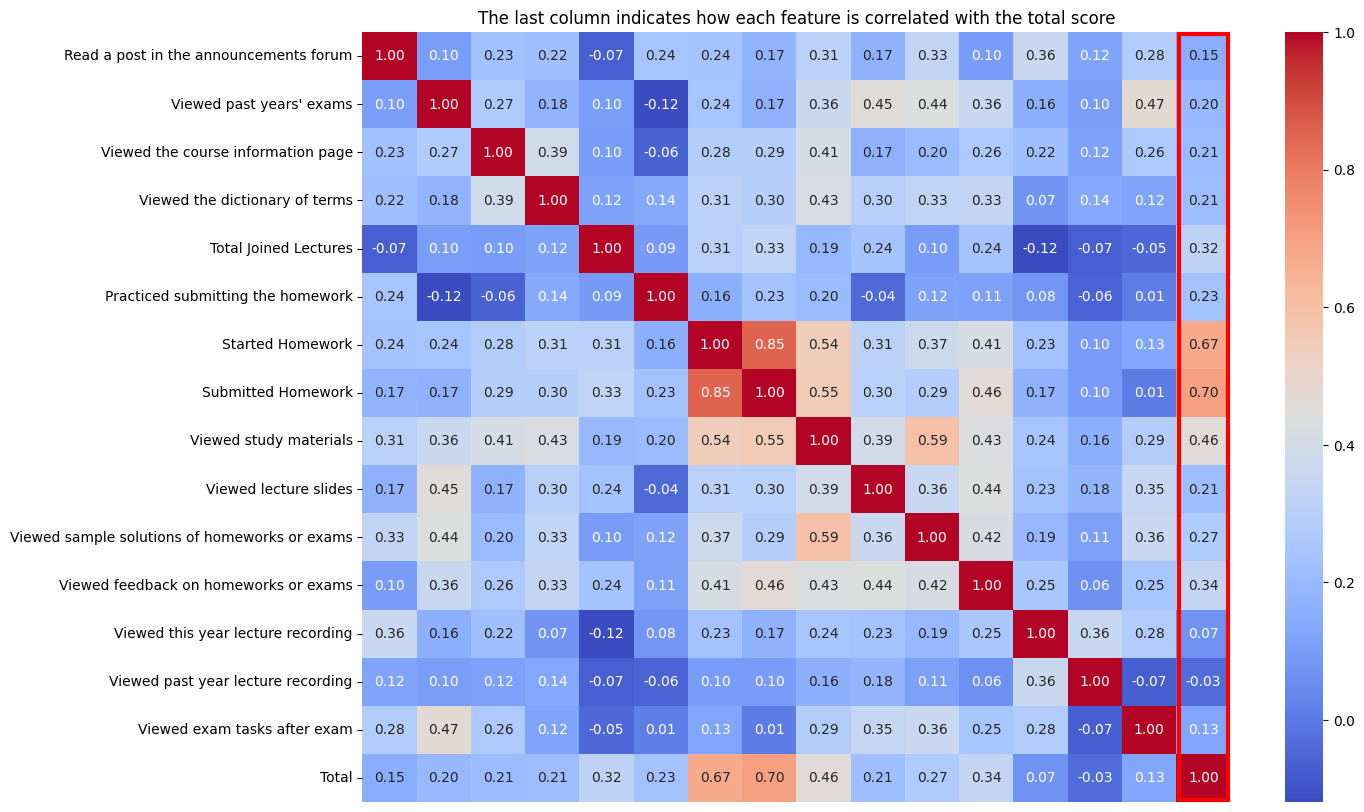

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_A_visual_points.corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("The last column indicates how each feature is correlated with the total score")

ax = plt.gca()
num_columns = df_A_visual_points.shape[1]  # Number of columns
ax.add_patch(plt.Rectangle((num_columns - 1 + 0.05, 0.05), 0.9, num_columns - 0.1,
                           fill=False, edgecolor='red', lw=3, clip_on=False))
ax.axes.get_xaxis().set_visible(False)

plt.show()

As we can see from the following regression plots per each feature, visually, the least influencial to the total score are: viewing lecture recordings and checking the validity of the homework before submitting it (practiced submitting). It becomes clear also that basically everyone who started and/or submitted more than 10 homeworks get at least 80% of the total score.

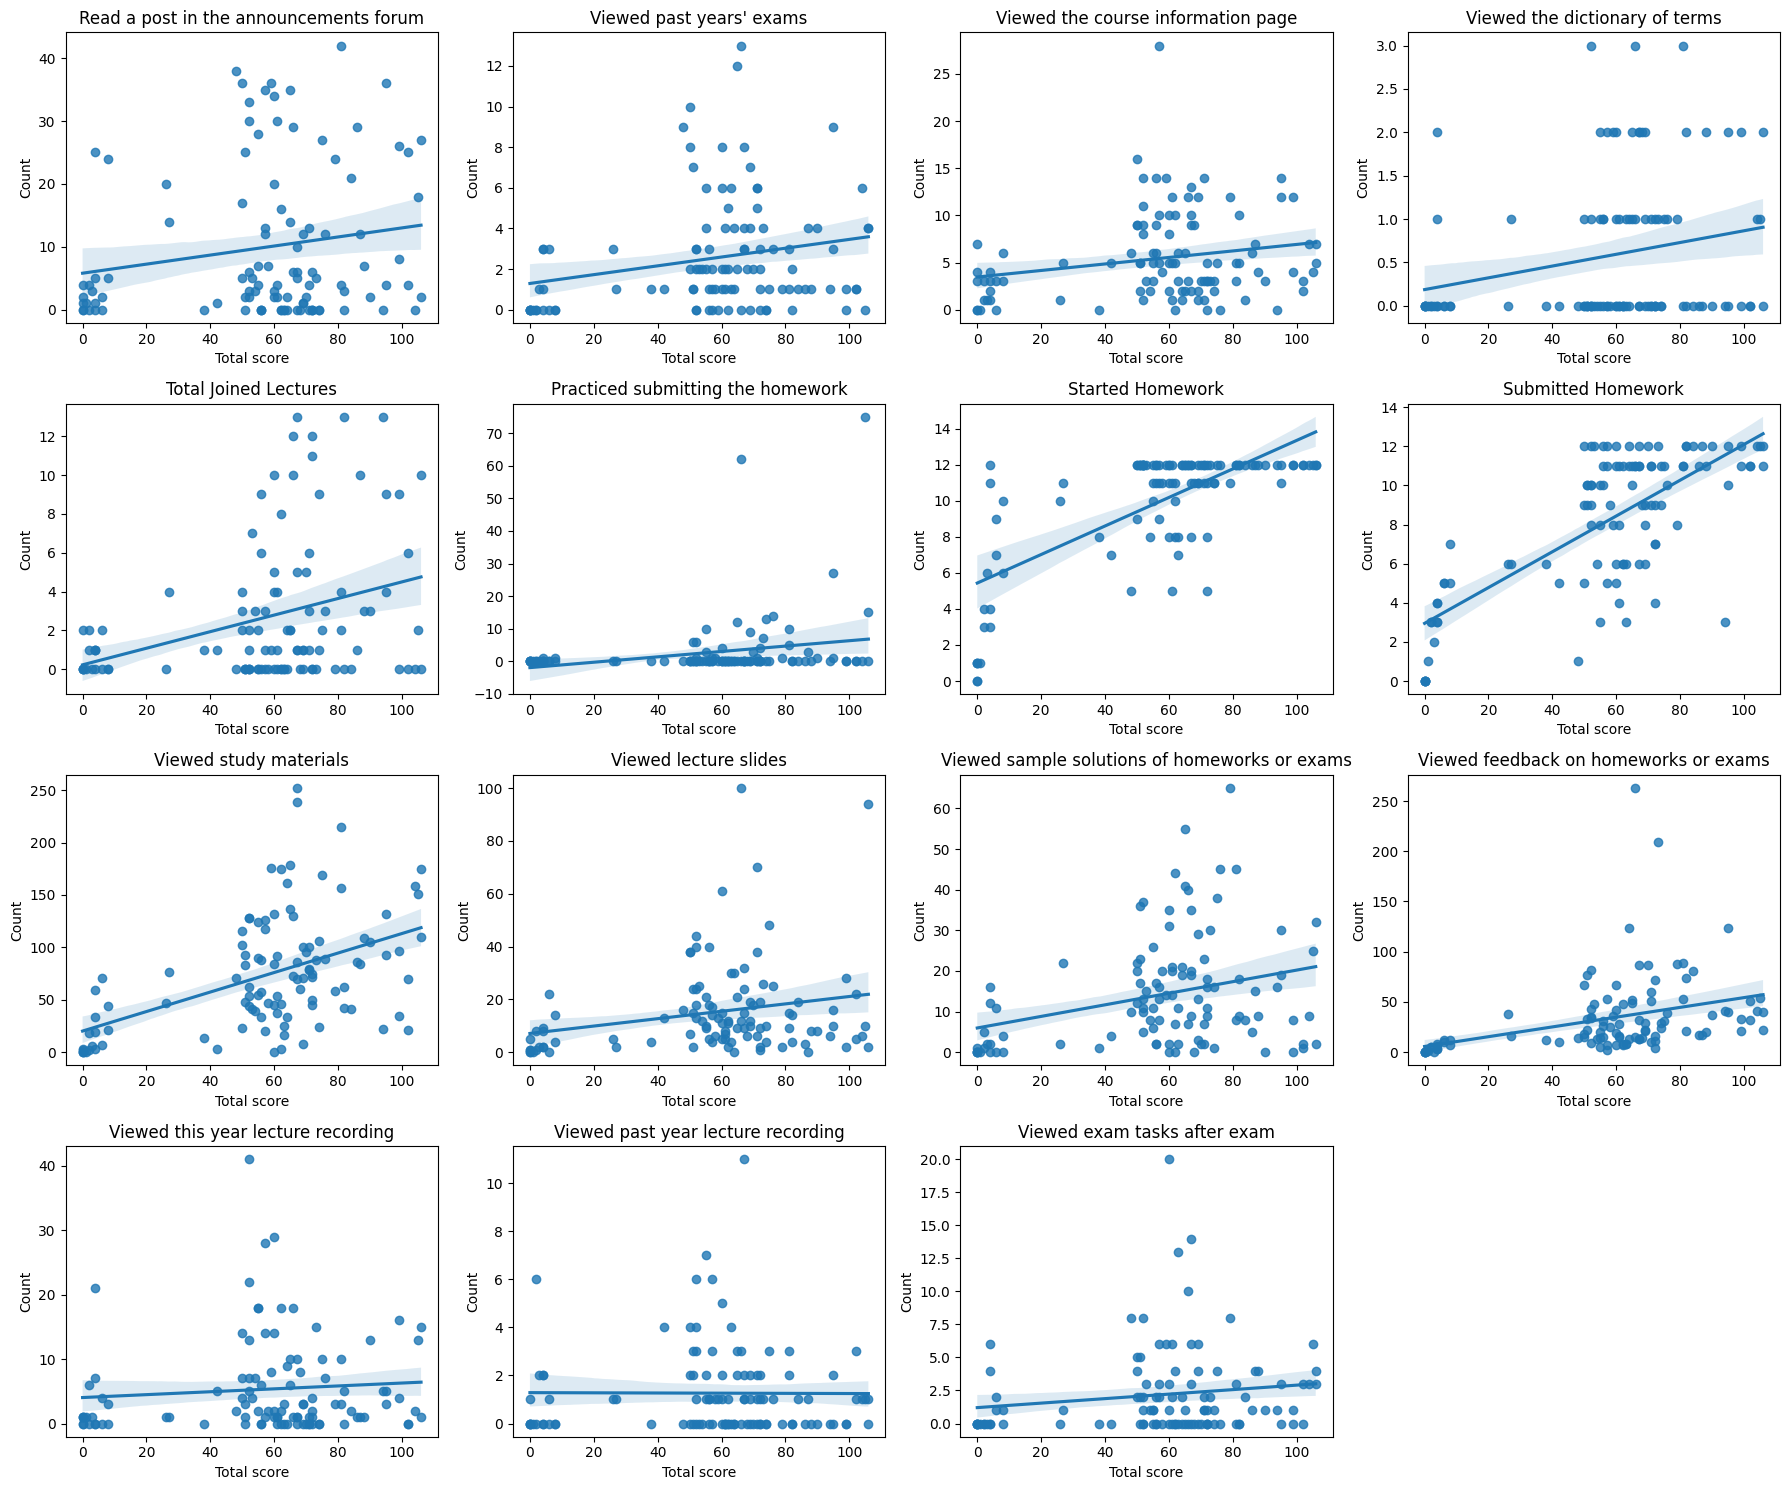

In [ ]:
# Scatter plots with regression lines for each activity vs. Total
df_A_visual_points = df_A_visual_points.replace(np.nan, 0)
df_A_visual_points['Total'] = pd.to_numeric(df_A_visual_points['Total'], errors='coerce').round().astype(int)
plt.figure(figsize=(18, 15))
for i, column in enumerate(df_A_visual_points.columns[:-1], 1):
    plt.subplot(4, 4, i)
    sns.regplot(x="Total", y=column, data=df_A_visual_points)
    plt.title(f"{column}")
    plt.xlabel("Total score")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Results A

Top 5 features of biggest importance for dataset A (with correlation):
* Submitted Homework 0.7
* Started Homework 0.67
* Viewed study materials 0.46
* Viewed feedback on homeworks or exams 0.34
* Total Joined Lectures 0.32

##Visualizing dataset B

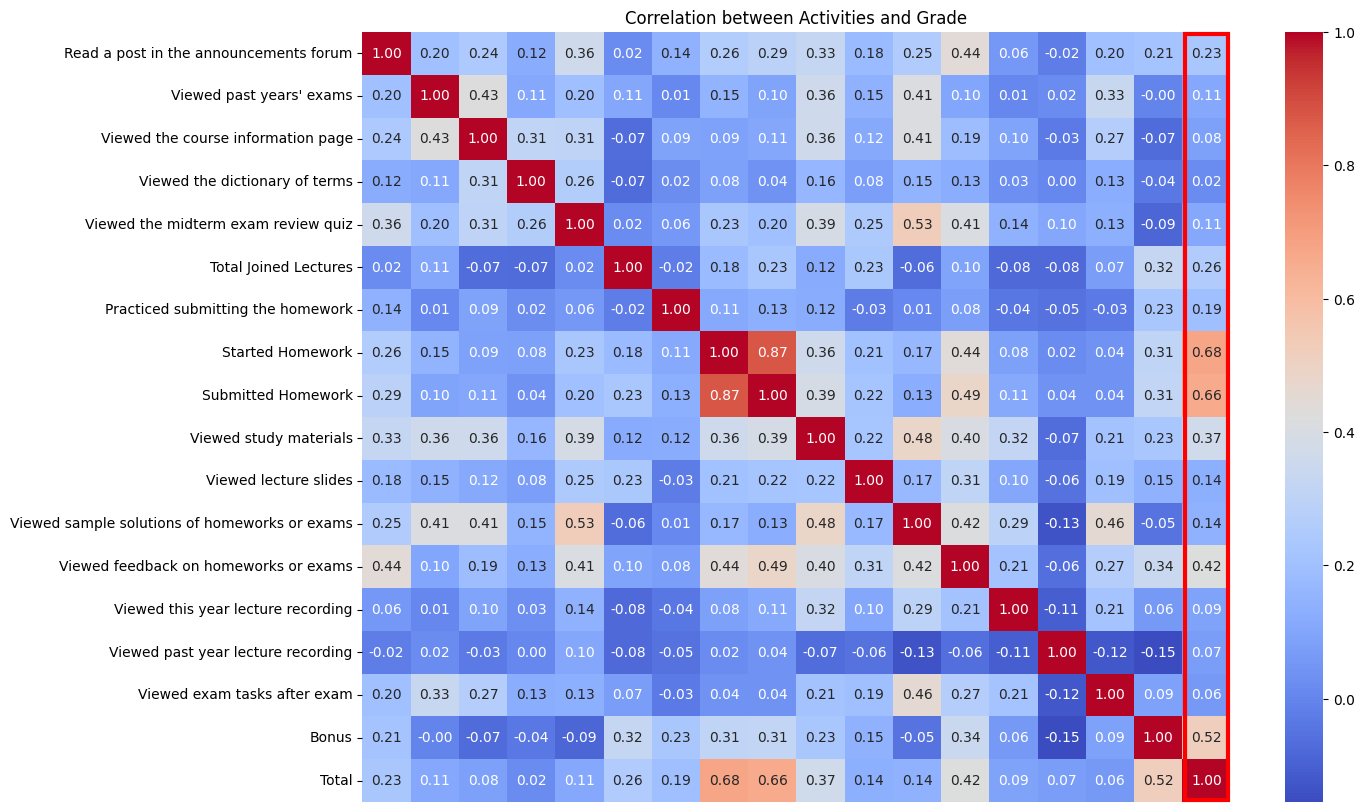

In [ ]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_B_visual_points.corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Correlation between Activities and Grade")

ax = plt.gca()
num_columns = df_B_visual_points.shape[1]  # Number of columns
ax.add_patch(plt.Rectangle((num_columns - 1 + 0.05, 0.05), 0.9, num_columns - 0.1,
                           fill=False, edgecolor='red', lw=3, clip_on=False))
ax.axes.get_xaxis().set_visible(False)

plt.show()

In addition to confirming the results of dataset A, this dataset shows that doing at least one bonus task is slightly increasing the chance of getting a better score.

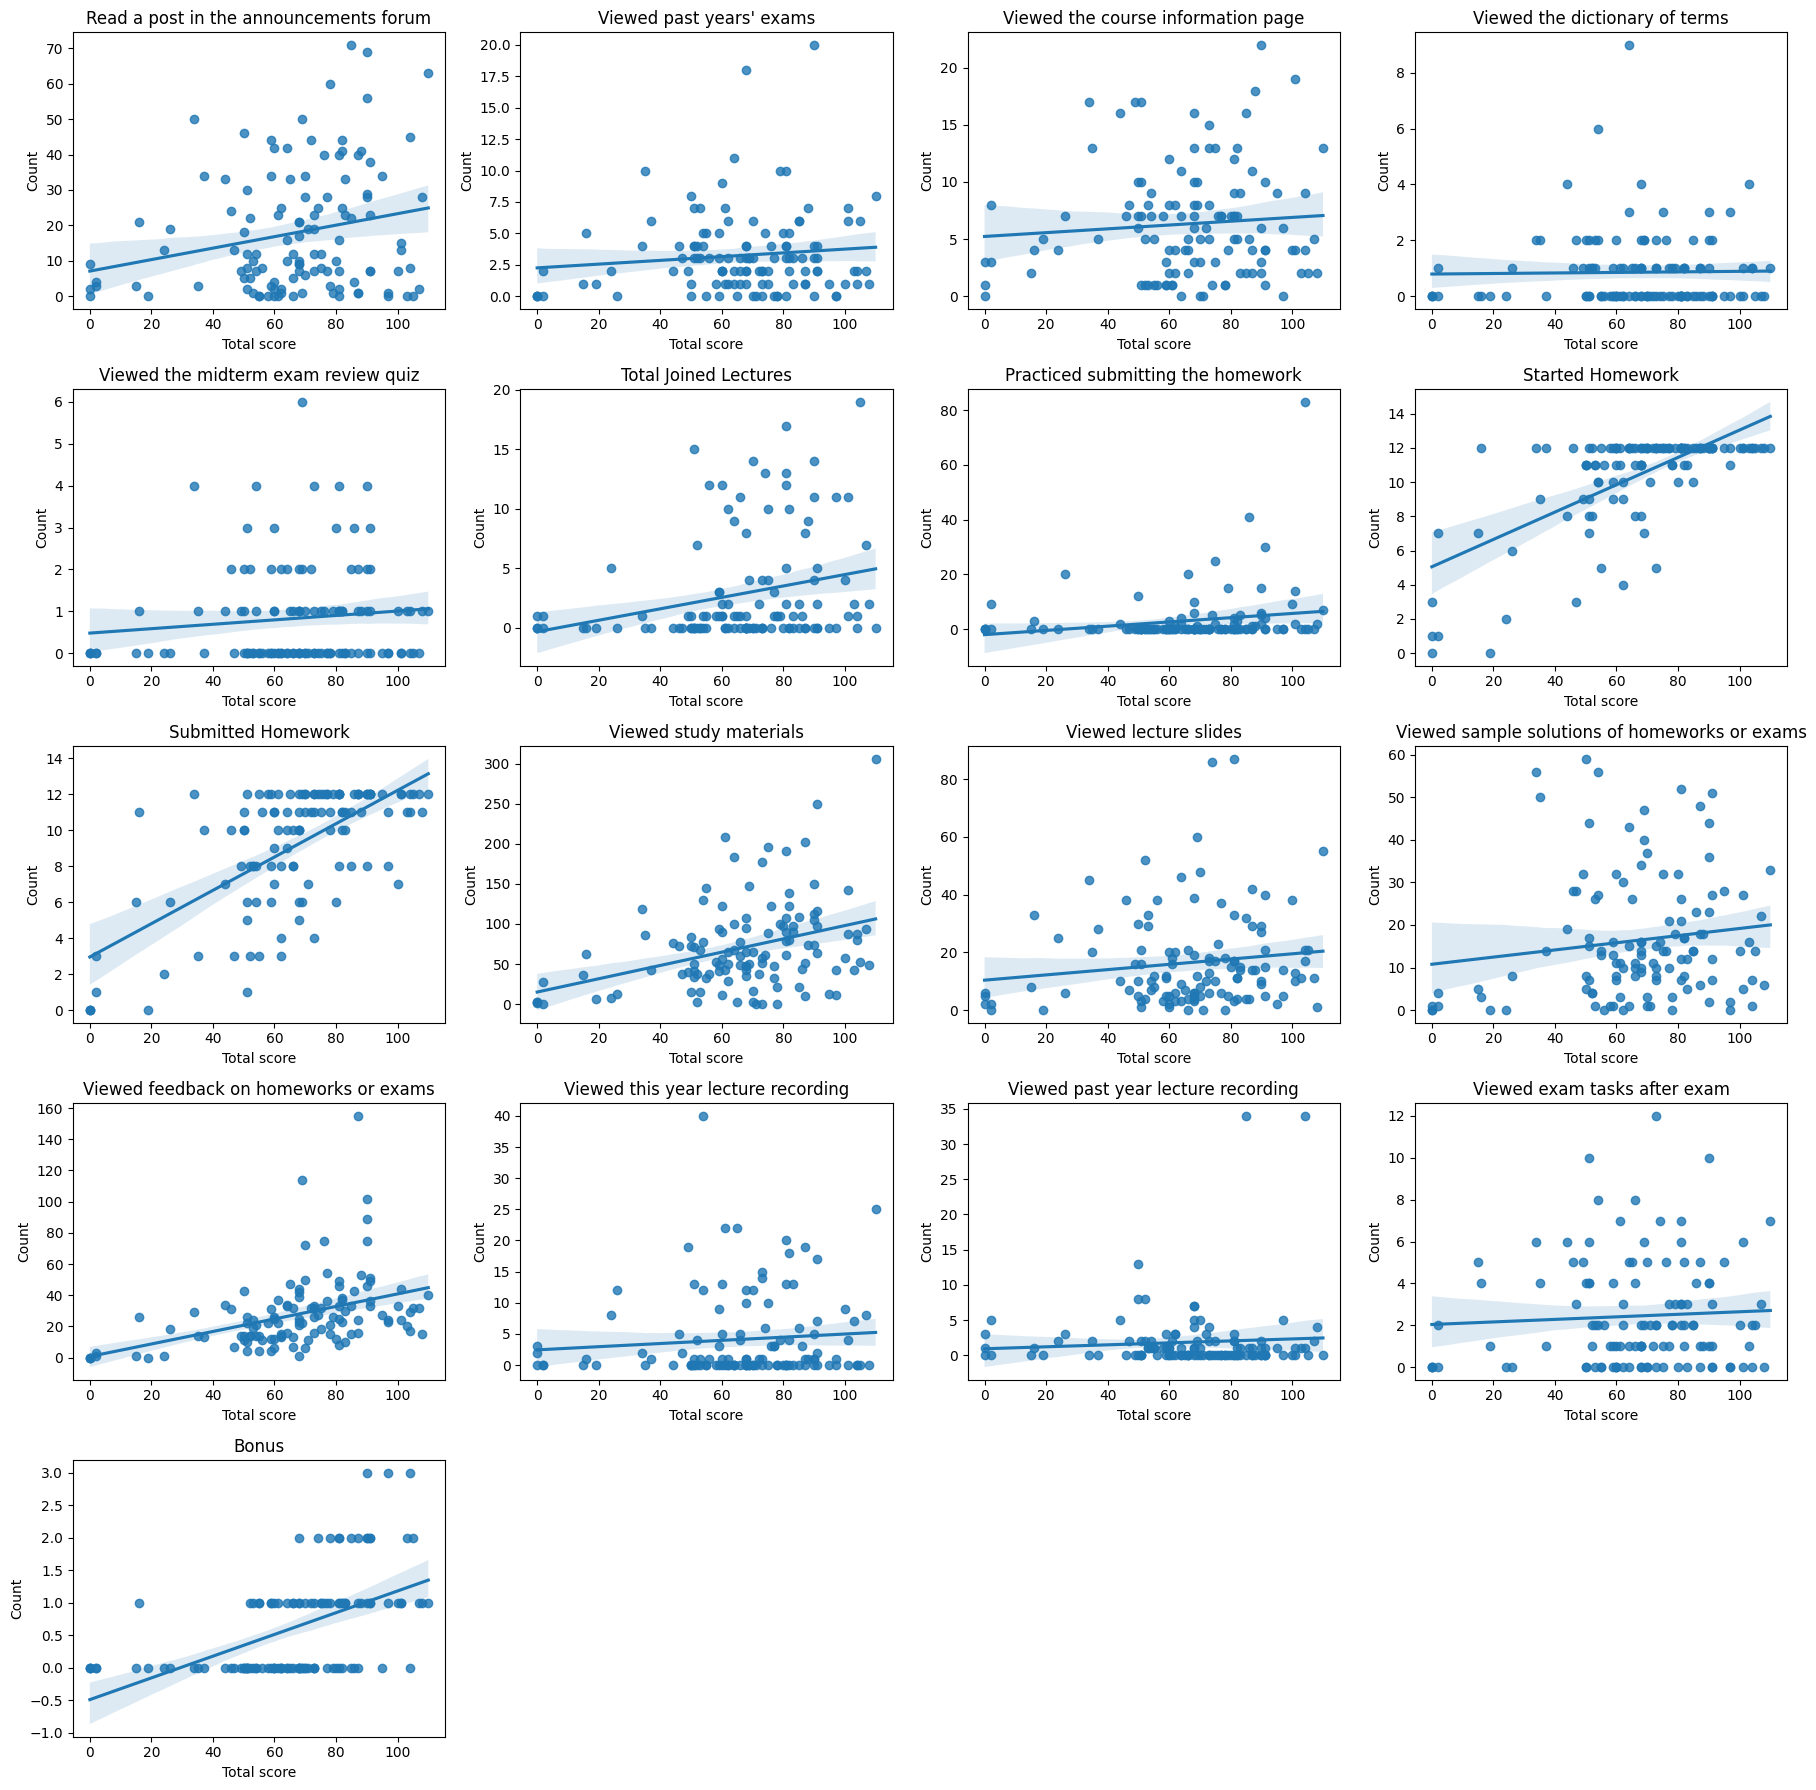

In [ ]:
# Scatter plots with regression lines for each activity vs. Total
df_B_visual_points = df_B_visual_points.replace(np.nan, 0)
df_B_visual_points['Total'] = pd.to_numeric(df_B_visual_points['Total'], errors='coerce').round().astype(int)
plt.figure(figsize=(18, 18))
for i, column in enumerate(df_B_visual_points.columns[:-1], 1):
    plt.subplot(5, 4, i)
    sns.regplot(x="Total", y=column, data=df_B_visual_points)
    plt.title(f"{column}")
    plt.xlabel("Total score")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

##Results B

Top 5 features of biggest importance for dataset B (with correlation):
* Started Homework 0.68
* Submitted Homework 0.66
* Bonus 0.52
* Viewed feedback on homeworks or exams 0.42
* Viewed study materials 0.37



```
# This is formatted as code
```

# ANOVA for significance

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_a_stat = df_A.copy()
df_a_stat = df_a_stat[df_a_stat['Grade'] != '-']

df_a_stat.columns = [col.replace(' ', '_') for col in df_a_stat.columns]
df_a_stat.columns = [col.replace("'", "") for col in df_a_stat.columns]

independent_variables = " + ".join(df_a_stat.columns.drop(['Grade', 'Total', 'Student']))
formula = f"Total ~ {independent_variables}"

# Ensure all columns except 'Grade', 'Total', and 'Student' are numeric
for col in df_a_stat.columns.drop(['Grade', 'Student']):
    df_a_stat[col] = pd.to_numeric(df_a_stat[col], errors='coerce')

model = ols(formula, data=df_a_stat).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
Read_a_post_in_the_announcements_forum,18.219549,1.0,0.046098,0.830494
Viewed_past_years_exams,229.563452,1.0,0.580830,0.448025
Viewed_the_course_information_page,106.717125,1.0,0.270010,0.604630
Viewed_the_dictionary_of_terms,14.123406,1.0,0.035734,0.850500
Total_Joined_Lectures,694.462480,1.0,1.757094,0.188418
Practiced_submitting_the_homework,272.226519,1.0,0.688774,0.408828
Started_Homework,1083.157445,1.0,2.740550,0.101393
Submitted_Homework,4095.475531,1.0,10.362164,0.001802
Viewed_study_materials,194.070434,1.0,0.491027,0.485318
Viewed_lecture_slides,271.139750,1.0,0.686024,0.409761


In [ ]:
df_b_stat = df_B.copy()
df_b_stat = df_b_stat[df_b_stat['Grade'] != '-']

df_b_stat.columns = [col.replace(' ', '_') for col in df_b_stat.columns]
df_b_stat.columns = [col.replace("'", "") for col in df_b_stat.columns]

independent_variables = " + ".join(df_b_stat.columns.drop(['Grade', 'Total', 'Student']))
formula = f"Total ~ {independent_variables}"

# Ensure all columns except 'Grade', 'Total', and 'Student' are numeric
for col in df_b_stat.columns.drop(['Grade', 'Student']):
    df_b_stat[col] = pd.to_numeric(df_b_stat[col], errors='coerce')

model = ols(formula, data=df_b_stat).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

anova_table

The ANOVA results indicate that most of the variables do not have a statistically significant effect on the Total score, with the exception of Submitted_Homework, which has a p-value of approximately 0.0018 (below the 0.05 threshold), indicating a significant effect.

So our main findings from ANOVA are:

Submitted_Homework shows a statistically significant impact on the Total score.
Other variables, such as Read_a_post_in_the_announcements_forum, Viewed_past_years_exams, and Viewed_the_course_information_page, have high p-values, suggesting they may not significantly affect Total in this model.


# Multi-Linear Regression Model

In [ ]:
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS, add_constant

df_A_MLR = df_A.copy()
df_A_MLR = df_A_MLR[df_A_MLR['Grade'] != '-']

df_A_MLR["Total"] = pd.to_numeric(df_A_MLR["Total"], errors="coerce")
df_A_MLR = df_A_MLR.dropna()

X = df_A_MLR.drop(columns=['Total', 'Student', 'Grade'])
y = pd.to_numeric(df_A_MLR['Total'], errors="coerce")

X_const = add_constant(X)

model_mlr = OLS(y, X_const).fit()
summary = model_mlr.summary()

coefficients = model_mlr.params
p_values = model_mlr.pvalues
r_squared = model_mlr.rsquared
adjusted_r_squared = model_mlr.rsquared_adj

results_summary = {
    "Coefficients": coefficients,
    "P-values": p_values,
    "R-squared": r_squared,
    "Adjusted R-squared": adjusted_r_squared,
    "Model Summary": summary
}

results_summary

{'Coefficients': const                                            1.190784
 Read a post in the announcements forum           0.042023
 Viewed past years' exams                         0.696375
 Viewed the course information page              -0.271533
 Viewed the dictionary of terms                  -0.530809
 Total Joined Lectures                            0.794590
 Practiced submitting the homework                0.180654
 Started Homework                                 2.141830
 Submitted Homework                               3.780005
 Viewed study materials                           0.038145
 Viewed lecture slides                           -0.120334
 Viewed sample solutions of homeworks or exams   -0.017052
 Viewed feedback on homeworks or exams           -0.007880
 Viewed this year lecture recording              -0.267506
 Viewed past year lecture recording              -0.491953
 Viewed exam tasks after exam                     1.088638
 dtype: float64,
 'P-values': const     

In [ ]:
df_B_MLR = df_B.copy()
df_B_MLR = df_B_MLR[df_B_MLR['Grade'] != '-']

df_B_MLR["Total"] = pd.to_numeric(df_B_MLR["Total"], errors="coerce")
df_B_MLR = df_B_MLR.dropna()

X = df_B_MLR.drop(columns=['Total', 'Student', 'Grade'])
y = pd.to_numeric(df_B_MLR['Total'], errors="coerce")

X_const = add_constant(X)

model_mlr = OLS(y, X_const).fit()
summary = model_mlr.summary()

coefficients = model_mlr.params
p_values = model_mlr.pvalues
r_squared = model_mlr.rsquared
adjusted_r_squared = model_mlr.rsquared_adj

results_summary = {
    "Coefficients": coefficients,
    "P-values": p_values,
    "R-squared": r_squared,
    "Adjusted R-squared": adjusted_r_squared,
    "Model Summary": summary
}

results_summary

Model Fit:

R-squared: 0.560, indicating that 56% of the variance in "Total" is explained by the predictors in the model.

Adjusted R-squared: 0.485, adjusting for the number of predictors, still suggesting a moderate fit.


Significant Predictors:
Submitted Homework: Coefficient = 3.78, p=0.002
Interpretation: For every additional homework submitted, the "Total" score increases by approximately 3.78, holding other factors constant. This is a statistically significant effect.

Other predictors, such as "Started Homework" and "Viewed exam tasks after exam," approach significance (p≈0.10-0.16) but do not meet conventional thresholds.


Non-Significant Predictors:
Variables like "Read a post in the announcements forum" (p=0.83) and "Viewed study materials" (p=0.49) show no significant relationship with "Total." Their coefficients are small and/or not statistically significant.

Some predictors even have negative coefficients (e.g., "Viewed lecture slides" at -0.12) but are not statistically meaningful (p>0.40).

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)

In [ ]:
# y_pred = lr_model.predict(X_test)

# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)
# print(f"Mean Squared Error: {mse}")
# print(f"R-squared: {r2}")

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.scatter(y_test, y_pred, alpha=0.7)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
# plt.xlabel("Actual Total")
# plt.ylabel("Predicted Total")
# plt.title("Actual vs. Predicted Total using Linear Regression")
# plt.show()

# PCA
* PCA - to discover main features that could describe the Grade - Aksel & Peeter



## Dataset A

In [ ]:
import matplotlib.pyplot as plt
!pip install -q plotnine
from plotnine import *
from sklearn.decomposition import PCA
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [ ]:
pca_to_drop = ["Student", "Total", "Grade"]
df_A_pca = df_A_test.drop(columns=pca_to_drop)

In [ ]:
#X = df_A_pca.drop(columns=['Total', 'Grade'])
X = df_A_pca.copy().drop(columns=['Grade_binary'])
feature_names = X.columns
y = df_A_pca['Grade_binary']
X_scaled = StandardScaler().fit_transform(X)

# Apply PCA
pca_09 = PCA(n_components=0.80)  # Keep 90% variance
X_pca = pca_09.fit_transform(X_scaled)

components = pd.DataFrame(pca_09.components_, columns=feature_names)

explained_variance = pca_09.explained_variance_ratio_

# Compute the weighted contribution for each feature
weighted_contributions = (components.abs().T * explained_variance).sum(axis=1)

# Sort features by their total weighted contribution
top_features = weighted_contributions.sort_values(ascending=False).head(3)

print("Top 3 features that explain the variance:")
print(top_features)

bottom_features = weighted_contributions.sort_values(ascending=True).head(2)

print("Bottom 2 features that contribute least to the variance:")
print(bottom_features)

Top 3 features that explain the variance:
Viewed lecture slides                            0.198796
Viewed this year lecture recording               0.194894
Viewed sample solutions of homeworks or exams    0.190478
dtype: float64
Bottom 2 features that contribute least to the variance:
Viewed study materials    0.167823
Total Joined Lectures     0.173407
dtype: float64


The first five features: Viewed study materials,	Started Homework,	Submitted Homework,	Viewed sample solutions of homeworks or exams, Viewed feedback on homeworks or exams, contribute most to PC1

## Dataset B

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [ ]:
df_B_pca = df_B.copy()
df_B_pca = df_B_pca[df_B_pca['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_B_pca['Grade_binary'] = df_B_pca['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_B_pca['Grade_encoded'] = label_encoder.fit_transform(df_B_pca['Grade'])

# Separate features and target variable
X = df_B_pca.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_B_pca['Grade_binary']  # Target variable is 'Grade_binary'


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Apply PCA
pca_09 = PCA(n_components=0.9)  # Keep 90% variance
X_pca = pca_09.fit_transform(X_scaled)

components = pd.DataFrame(pca_09.components_, columns=feature_names)

explained_variance = pca_09.explained_variance_ratio_

# Compute the weighted contribution for each feature
weighted_contributions = (components.abs().T * explained_variance).sum(axis=1)

# Sort features by their total weighted contribution
top_features = weighted_contributions.sort_values(ascending=False).head(3)

print("Top 3 features across 13 PCAs that explain the variance:")
print(top_features)

bottom_features = weighted_contributions.sort_values(ascending=True).head(2)

print("Bottom 2 features across 13 PCAs that contribute least to the variance:")
print(bottom_features)

Top 3 features that explain the variance:
Viewed the course information page     0.198934
Viewed the midterm exam review quiz    0.196627
Viewed exam tasks after exam           0.196457
dtype: float64
Bottom 2 features that contribute least to the variance:
Practiced submitting the homework     0.154518
Viewed past year lecture recording    0.157817
dtype: float64


# Random Forest
* Random Forest - Kirill


**Dataset A**

In [ ]:
df_copy_A = df_A.copy()
df_copy_A.head()

,Student,Read a post in the announcements forum,Viewed past years' exams,Viewed the course information page,Viewed the dictionary of terms,Total Joined Lectures,Practiced submitting the homework,Started Homework,Submitted Homework,Viewed study materials,Viewed lecture slides,Viewed sample solutions of homeworks or exams,Viewed feedback on homeworks or exams,Viewed this year lecture recording,Viewed past year lecture recording,Viewed exam tasks after exam,Total,Grade
0,A001,0.0,0.0,2.0,0.0,1.0,13.0,11.0,11.0,106.0,4.0,16.0,24.0,0.0,0.0,0.0,74.28,C
1,A002,25.0,1.0,3.0,0.0,6.0,0.0,12.0,11.0,70.0,22.0,2.0,51.0,0.0,3.0,0.0,102.2,A
2,A003,1.0,0.0,2.0,0.0,1.0,1.0,4.0,3.0,19.0,2.0,0.0,3.0,7.0,0.0,0.0,3.53,-
3,A004,12.0,1.0,28.0,2.0,1.0,0.0,12.0,12.0,118.0,14.0,8.0,53.0,14.0,3.0,3.0,57.26,E
4,A005,36.0,3.0,12.0,2.0,4.0,27.0,12.0,12.0,132.0,10.0,19.0,124.0,3.0,0.0,3.0,95.05,A


In [ ]:
df_copy_A = df_copy_A[df_copy_A['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_copy_A['Grade_binary'] = df_copy_A['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_copy_A['Grade_encoded'] = label_encoder.fit_transform(df_copy_A['Grade'])

# Separate features and target variable
X = df_copy_A.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_copy_A['Grade_binary']  # Target variable is 'Grade_binary'



# # Remove rows where 'Grade' contains '-'
# df_copy_A = df_copy_A[df_copy_A['Grade'] != '-']

# # Label Encoding for the 'Grade' column (converting grades to numeric values)
# label_encoder = LabelEncoder()
# df_copy_A['Grade'] = label_encoder.fit_transform(df_copy_A['Grade'])

# # Separate features and target variable
# X = df_copy_A.drop(columns=['Student', 'Grade', 'Total'])  # Drop non-numeric columns like 'Student' and 'Grade'
# y = df_copy_A['Grade']  # Target variable is 'Grade'

# df_copy_A

<ipython-input-299-0548bb859527>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_A['Grade_binary'] = df_copy_A['Grade'].map(binary_map)
<ipython-input-299-0548bb859527>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_A['Grade_encoded'] = label_encoder.fit_transform(df_copy_A['Grade'])


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [ ]:
# Output the evaluation metrics
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

feature_importances = rf_model.feature_importances_
features = {}
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance}")
    features[feature] = importance

Mean Squared Error: 0.1735833333333333
R-squared: -0.004303571428571296
Read a post in the announcements forum: 0.05284916690315166
Viewed past years' exams: 0.03367059176284662
Viewed the course information page: 0.06670154091775654
Viewed the dictionary of terms: 0.01331285788274255
Total Joined Lectures: 0.10658307665133457
Practiced submitting the homework: 0.040738517094870745
Started Homework: 0.020776797997088946
Submitted Homework: 0.1486847531490726
Viewed study materials: 0.08820206936508396
Viewed lecture slides: 0.08904319889388368
Viewed sample solutions of homeworks or exams: 0.12611007750232875
Viewed feedback on homeworks or exams: 0.12996710839967396
Viewed this year lecture recording: 0.027836706112280535
Viewed past year lecture recording: 0.03866344649800233
Viewed exam tasks after exam: 0.016860090869882636


In [ ]:
print("Main three features that affects on the grade: ", *sorted(features.items(), key=lambda x: -x[1])[:3], sep='\n')

Main three features that affects on the grade: 
('Submitted Homework', 0.1486847531490726)
('Viewed feedback on homeworks or exams', 0.12996710839967396)
('Viewed sample solutions of homeworks or exams', 0.12611007750232875)


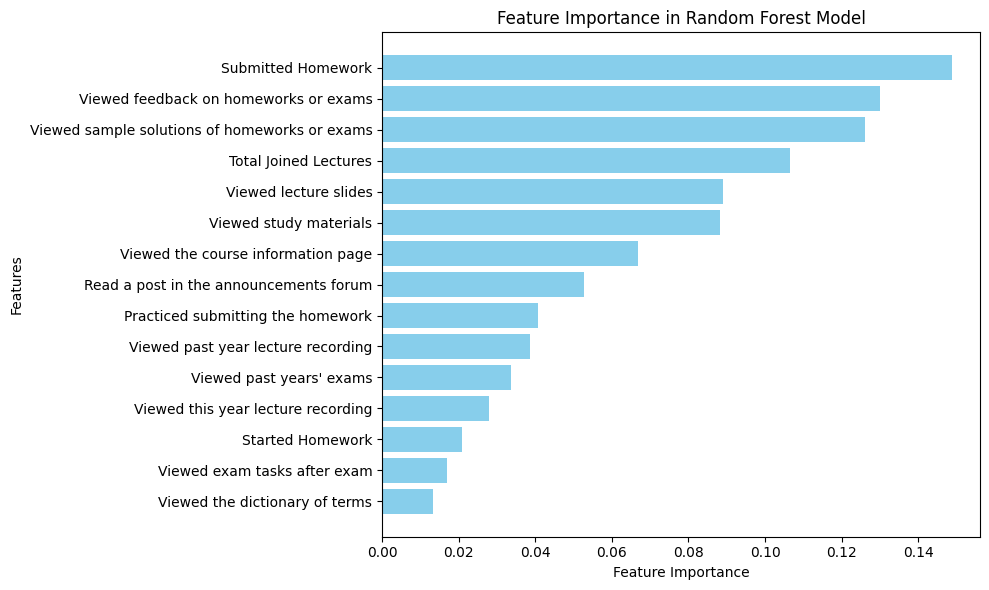

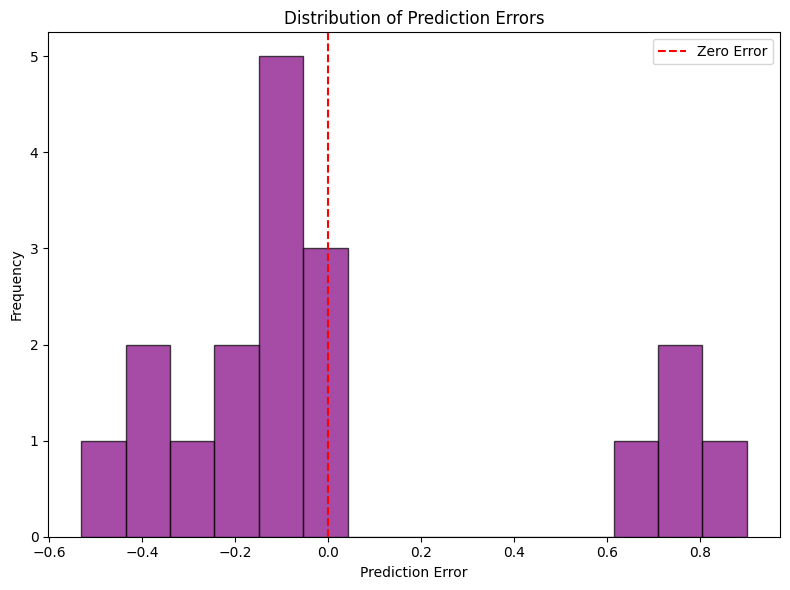

In [ ]:
sorted_features = sorted(features.items(), key=lambda x: -x[1])
labels, importances = zip(*sorted_features)

plt.figure(figsize=(10, 6))
plt.barh(labels, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


errors = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=15, color='purple', alpha=0.7, edgecolor='k')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.tight_layout()
plt.show()

**Dataset B**

In [ ]:
df_copy_B = df_B.copy()
df_copy_B.head()

,Student,Read a post in the announcements forum,Viewed past years' exams,Viewed the course information page,Viewed the dictionary of terms,Viewed the midterm exam review quiz,Total Joined Lectures,Practiced submitting the homework,Started Homework,Submitted Homework,Viewed study materials,Viewed lecture slides,Viewed sample solutions of homeworks or exams,Viewed feedback on homeworks or exams,Viewed this year lecture recording,Viewed past year lecture recording,Viewed exam tasks after exam,Bonus,Total,Grade
0,B001,9.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,6.0,0.0,0.0,3.0,3.0,0.0,0,0.00,-
1,B002,10.0,1.0,7.0,9.0,2.0,0.0,4.0,12.0,9.0,68.0,46.0,1.0,33.0,0.0,0.0,0.0,0,64.07,D
2,B003,1.0,1.0,4.0,0.0,1.0,0.0,0.0,12.0,12.0,10.0,42.0,18.0,24.0,0.0,0.0,1.0,0,87.37,B
3,B004,40.0,10.0,7.0,0.0,4.0,13.0,0.0,12.0,12.0,191.0,17.0,52.0,49.0,13.0,3.0,7.0,2,80.90,B
4,B005,7.0,2.0,4.0,0.0,0.0,5.0,0.0,12.0,12.0,64.0,5.0,12.0,33.0,2.0,1.0,1.0,1,91.47,A


In [ ]:
df_copy_B = df_copy_B[df_copy_B['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_copy_B['Grade_binary'] = df_copy_B['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_copy_B['Grade_encoded'] = label_encoder.fit_transform(df_copy_B['Grade'])

# Separate features and target variable
X = df_copy_B.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_copy_B['Grade_binary']  # Target variable is 'Grade_binary'

<ipython-input-308-398abe4bea32>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_B['Grade_binary'] = df_copy_B['Grade'].map(binary_map)
<ipython-input-308-398abe4bea32>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_copy_B['Grade_encoded'] = label_encoder.fit_transform(df_copy_B['Grade'])


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.16157391304347826
R-squared: 0.34251846153846155


In [ ]:
feature_importances = rf_model.feature_importances_
features = {}
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance}")
    features[feature] = importance

Read a post in the announcements forum: 0.06578954019318713
Viewed past years' exams: 0.029602759478682898
Viewed the course information page: 0.06312082564747575
Viewed the dictionary of terms: 0.03618102053897048
Viewed the midterm exam review quiz: 0.01985682343132429
Total Joined Lectures: 0.04850178532063014
Practiced submitting the homework: 0.03760267964717345
Started Homework: 0.044788342609652226
Submitted Homework: 0.035361257998452925
Viewed study materials: 0.10998597264730389
Viewed lecture slides: 0.09123866087376122
Viewed sample solutions of homeworks or exams: 0.042352203241723944
Viewed feedback on homeworks or exams: 0.07793776714141057
Viewed this year lecture recording: 0.02257753672158701
Viewed past year lecture recording: 0.03469458595300827
Viewed exam tasks after exam: 0.0388858755373038
Bonus: 0.2015223630183521


In [ ]:
print("Main three features that affects on the grade: ", *sorted(features.items(), key=lambda x: -x[1])[:3], sep='\n')

Main three features that affects on the grade: 
('Bonus', 0.2015223630183521)
('Viewed study materials', 0.10998597264730389)
('Viewed lecture slides', 0.09123866087376122)


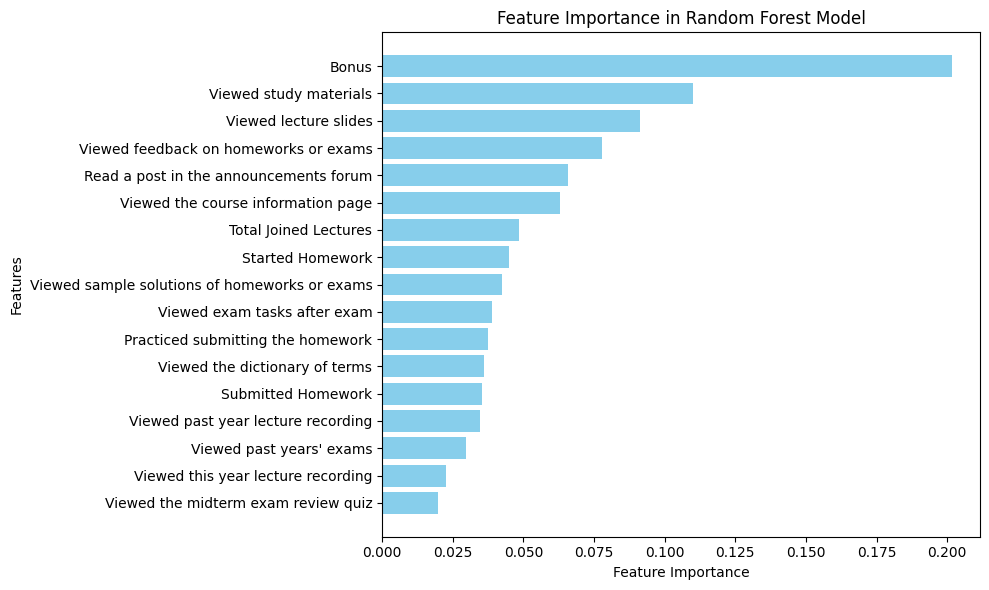

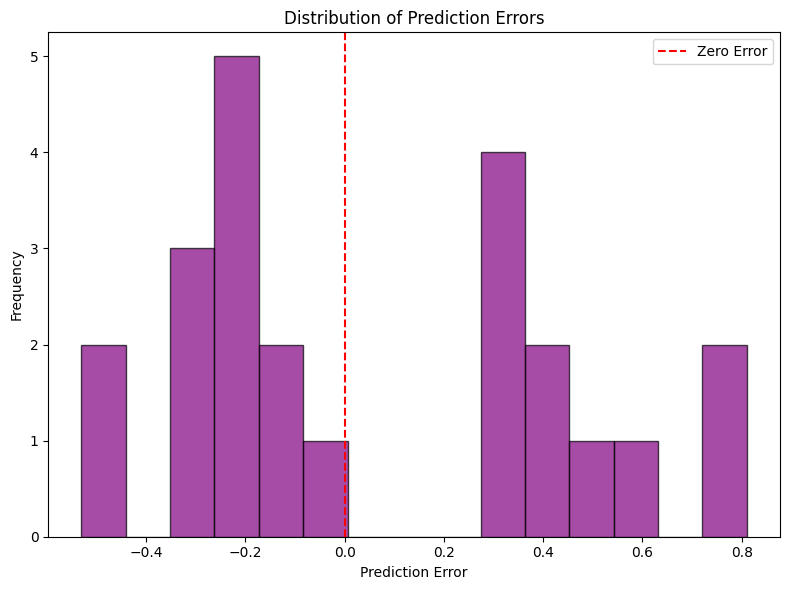

In [ ]:
sorted_features = sorted(features.items(), key=lambda x: -x[1])
labels, importances = zip(*sorted_features)

plt.figure(figsize=(10, 6))
plt.barh(labels, importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


errors = y_test - y_pred
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=15, color='purple', alpha=0.7, edgecolor='k')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.legend()
plt.tight_layout()
plt.show()

# Logistic Regression
Peeter

##Dataset A

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from statsmodels.api import Logit, add_constant

# Copy and preprocess the data
df_A_lr = df_A.copy()

# Drop rows with "-" in any column
df_A_lr = df_A_lr[(df_A_lr != "-").all(axis=1)]

# Create binary grade column
df_A_lr["Grade_binary"] = df_A_lr["Grade"].map(lambda x: 1 if x in ["A", "B"] else 0)

# Drop rows with missing grades
df_A_lr = df_A_lr.dropna(subset=["Grade_binary"])

# Prepare data for logistic regression
X = df_A_lr.drop(columns=["Student", "Total", "Grade", "Grade_binary"])
feature_names = X.columns.tolist()
y = df_A_lr["Grade_binary"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add a constant to the model
X_train_const = add_constant(X_train_scaled)
X_test_const = add_constant(X_test_scaled)

# Fit the logistic regression model using statsmodels
logit_model = Logit(y_train, X_train_const).fit()

# Make predictions on the test set
y_pred_probs = logit_model.predict(X_test_const)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Extract results
summary = logit_model.summary()
coefficients = logit_model.params
p_values = logit_model.pvalues
pseudo_r_squared = logit_model.prsquared

# Create a DataFrame for coefficients and feature names
import pandas as pd
coef_df = pd.DataFrame({"Feature": ["const"] + feature_names, "Coefficient": coefficients.values, "P-value": p_values.values})

# Classification report
classification_rep = classification_report(y_test, y_pred)

results_summary = {
    "Coefficients": coef_df,
    "Pseudo R-squared": pseudo_r_squared,
    "Model Summary": summary,
    "Accuracy": accuracy,
    "Classification Report": classification_rep
}

# Display the results
print("Coefficients:\n", coef_df)
print("\nPseudo R-squared:", pseudo_r_squared)
print("\nModel Summary:\n", summary)
print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_rep)

Optimization terminated successfully.
         Current function value: 0.348152
         Iterations 9
Coefficients:
                                           Feature  Coefficient   P-value
0                                           const    -2.824969  0.005076
1          Read a post in the announcements forum     0.486505  0.295962
2                        Viewed past years' exams    -0.009154  0.986363
3              Viewed the course information page    -0.573953  0.262948
4                  Viewed the dictionary of terms    -0.296215  0.589890
5                           Total Joined Lectures    -0.004937  0.989936
6               Practiced submitting the homework    -0.059310  0.849386
7                                Started Homework     2.549875  0.173057
8                              Submitted Homework     0.271609  0.669420
9                          Viewed study materials     0.961904  0.070321
10                          Viewed lecture slides    -0.073704  0.864918
11  Vie

The best combinations of features are:

('Read a post in the announcements forum',
 'Viewed the course information page',
 'Practiced submitting the homework',
 'Submitted Homework',
 'Viewed lecture slides',
 'Viewed sample solutions of homeworks or exams',
 'Viewed this year lecture recording')

 and

 ("Viewed past years' exams",
 'Total Joined Lectures',
 'Submitted Homework',
 'Viewed sample solutions of homeworks or exams',
 'Viewed feedback on homeworks or exams').

 Both got an accuracy of 0.46875.

##Results A

One of the features which stands out is 'Viewed sample solutions of homeworks or exams'.
It was the only one with a p-value below 0.05 (0.031)

##Dataset B

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from statsmodels.api import Logit, add_constant

# Copy and preprocess the data
df_B_lr = df_B.copy()

# Drop rows with "-" in any column
df_B_lr = df_B_lr[(df_B_lr != "-").all(axis=1)]

# Create binary grade column
df_B_lr["Grade_binary"] = df_B_lr["Grade"].map(lambda x: 1 if x in ["A", "B"] else 0)

# Drop rows with missing grades
df_B_lr = df_B_lr.dropna(subset=["Grade_binary"])

# Prepare data for logistic regression
X = df_B_lr.drop(columns=["Student", "Total", "Grade", "Grade_binary"])
feature_names = X.columns.tolist()
y = df_B_lr["Grade_binary"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add a constant to the model
X_train_const = add_constant(X_train_scaled)
X_test_const = add_constant(X_test_scaled)

# Fit the logistic regression model using statsmodels
logit_model = Logit(y_train, X_train_const).fit()

# Make predictions on the test set
y_pred_probs = logit_model.predict(X_test_const)
y_pred = (y_pred_probs >= 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Extract results
summary = logit_model.summary()
coefficients = logit_model.params
p_values = logit_model.pvalues
pseudo_r_squared = logit_model.prsquared

# Create a DataFrame for coefficients and feature names
import pandas as pd
coef_df = pd.DataFrame({"Feature": ["const"] + feature_names, "Coefficient": coefficients.values, "P-value": p_values.values})

# Classification report
classification_rep = classification_report(y_test, y_pred)

results_summary = {
    "Coefficients": coef_df,
    "Pseudo R-squared": pseudo_r_squared,
    "Model Summary": summary,
    "Accuracy": accuracy,
    "Classification Report": classification_rep
}

# Display the results
print("Coefficients:\n", coef_df)
print("\nPseudo R-squared:", pseudo_r_squared)
print("\nModel Summary:\n", summary)
print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_rep)

Optimization terminated successfully.
         Current function value: 0.390243
         Iterations 8
Coefficients:
                                           Feature  Coefficient   P-value
0                                           const    -1.555349  0.003676
1          Read a post in the announcements forum    -0.131778  0.698989
2                        Viewed past years' exams    -0.125144  0.740795
3              Viewed the course information page     0.461699  0.196362
4                  Viewed the dictionary of terms    -0.502848  0.159895
5             Viewed the midterm exam review quiz     0.232890  0.563357
6                           Total Joined Lectures    -0.003778  0.991638
7               Practiced submitting the homework     0.240784  0.577691
8                                Started Homework     1.826381  0.147008
9                              Submitted Homework    -0.025549  0.971108
10                         Viewed study materials     0.168981  0.634218
11     

The best combination of features is:

('Read a post in the announcements forum',
 "Viewed past years' exams",
 'Viewed the course information page',
 'Viewed the midterm exam review quiz',
 'Total Joined Lectures',
 'Started Homework',
 'Viewed study materials',
 'Viewed sample solutions of homeworks or exams',
 'Viewed feedback on homeworks or exams',
 'Bonus').

 It got an accuracy of 0.5.

##Results B

The only feature which stands out is 'Bonus'.
It was the only one with a p-value below 0.05 (0.0057) and a coefficient higher than 1 (1.63).

If we take a look at all the models which were thrained with only one feature then the best model-features are (with accuracies):
* Bonus (0.27778)
* Started Homework (0.22222)
* Viewed study material (0.22222)
* Submitted Homework (0.22222)
* Practiced submitting the homework (0.19444)

# XGBoost
Peeter

## Dataset A

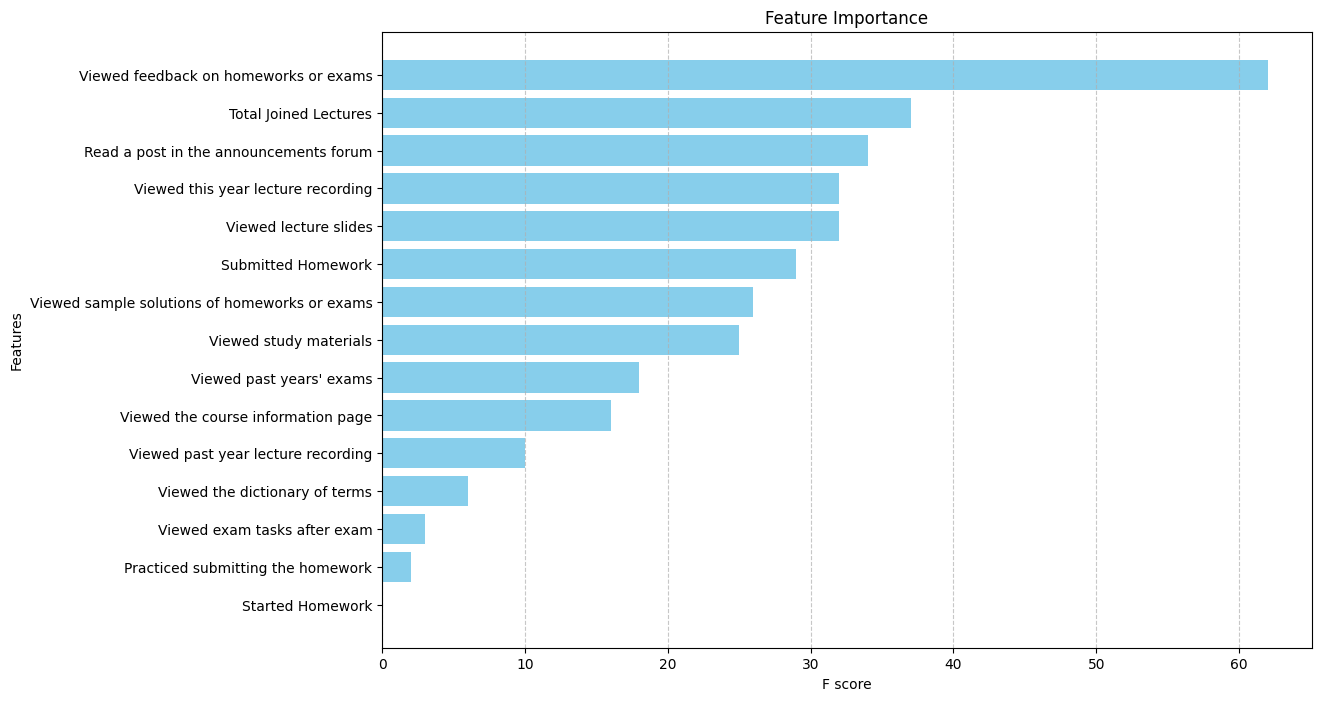

(0.2222222222222222,
 0.2222222222222222,
 -0.2857142857142856,
 0.7777777777777778)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create binary 'Grade_binary' column
df_A_xgb = df_A.copy()
df_A_xgb = df_A_xgb[df_A_xgb['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_A_xgb['Grade_binary'] = df_A_xgb['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_A_xgb['Grade_encoded'] = label_encoder.fit_transform(df_A_xgb['Grade'])

# Separate features and target variable
X = df_A_xgb.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_A_xgb['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the XGBoost model
model = XGBClassifier(
    n_estimators=100,  # Number of trees
    max_depth=3,       # Maximum depth of a tree
    learning_rate=0.1, # Step size shrinkage
    eval_metric='logloss'    # Metric for evaluation
)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Feature Importance Plot
feature_importances = model.get_booster().get_score(importance_type='weight')
feature_importance_values = np.array([feature_importances.get(f'f{i}', 0) for i in range(len(feature_names))])

sorted_idx = np.argsort(feature_importance_values)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = feature_importance_values[sorted_idx]

plt.figure(figsize=(12, 8))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.xlabel("F score")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Return metrics and sample predictions
mse, mae, r2, accuracy

##Results A

Top 5 features of biggest importance (with F-score):
* Viewed sample solutions of homeworks or exams (328)
* Viewed feedback on homeworks or exams (221)
* Submitted Homework (221)
* Viewed lecture slides (206)
* Viewed study materials (204)

## Dataset B

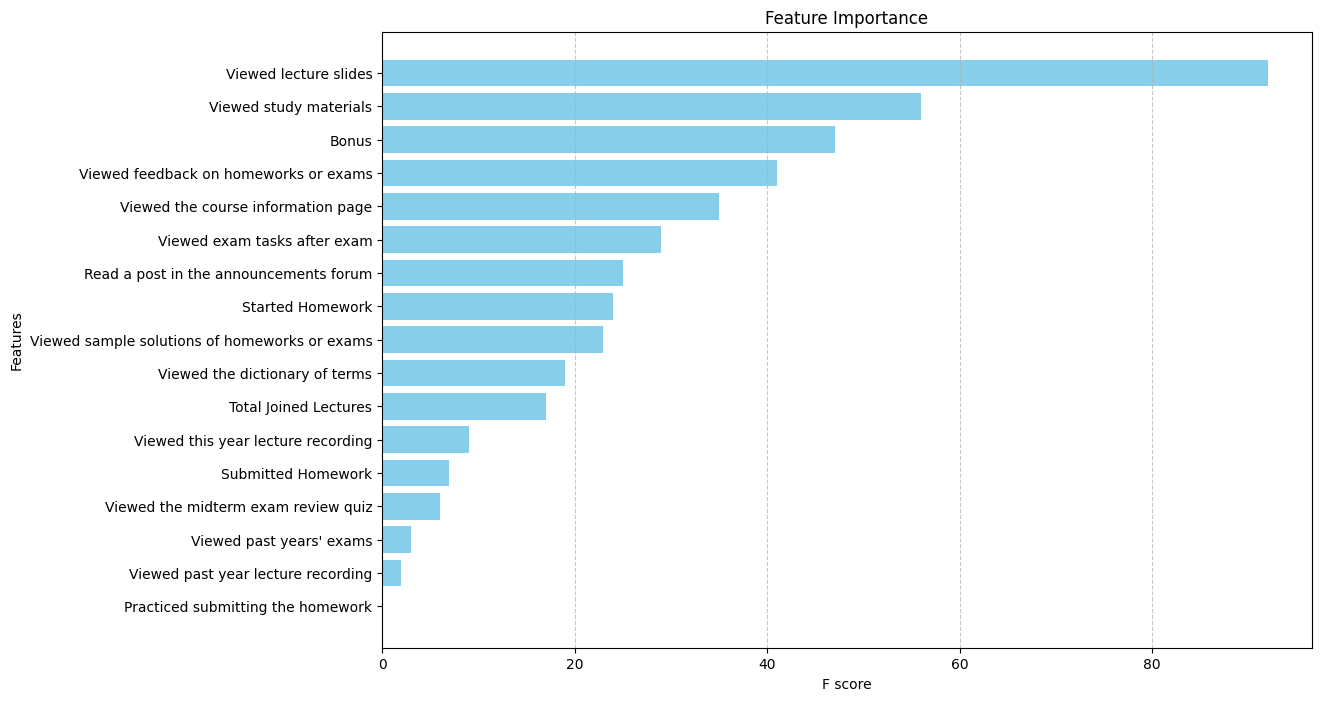

(0.2608695652173913,
 0.2608695652173913,
 -0.061538461538461764,
 0.7391304347826086)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create binary 'Grade_binary' column
df_B_xgb = df_B.copy()
df_B_xgb = df_B_xgb[df_B_xgb['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_B_xgb['Grade_binary'] = df_B_xgb['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_B_xgb['Grade_encoded'] = label_encoder.fit_transform(df_B_xgb['Grade'])

# Separate features and target variable
X = df_B_xgb.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_B_xgb['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the XGBoost model
model = XGBClassifier(
    n_estimators=100,  # Number of trees
    max_depth=3,       # Maximum depth of a tree
    learning_rate=0.1, # Step size shrinkage
    eval_metric='logloss'    # Metric for evaluation
)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

# Feature Importance Plot
feature_importances = model.get_booster().get_score(importance_type='weight')
feature_importance_values = np.array([feature_importances.get(f'f{i}', 0) for i in range(len(feature_names))])

sorted_idx = np.argsort(feature_importance_values)[::-1]
sorted_features = feature_names[sorted_idx]
sorted_importances = feature_importance_values[sorted_idx]

plt.figure(figsize=(12, 8))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.xlabel("F score")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Return metrics and sample predictions
mse, mae, r2, accuracy

##Results B

Top 5 features of biggest importance (with F-score):
* Viewed study materials (299)
* Read a post in the announcements forum (268)
* Viewed feedback on homeworks or exams (262)
* Viewed lecture slides (222)
* Viewed past years' exams (214)

#GRADES

In [ ]:
df_grades_A.head(3)

,Student,Total,Grade,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,Homework 7,...,Homework 9,Homework 10,Homework 11,Homework 12,Midterm exam,Midterm exam retake,Midterm exam retake 2,First final exam,Second final exam,Final exam retake
0,A001,74.28,C,110.0,97.0,100.0,96.0,97.0,86.0,68.0,...,65.0,70.0,70.0,-,73,-,-,74,-,-
1,A002,102.2,A,110.0,110.0,110.0,87.5,110.0,86.0,70.0,...,110.0,108.0,44.5,0.0,108,-,-,105,-,-
2,A003,3.53,-,100.0,92.0,20.0,0.0,-,-,-,...,-,-,-,-,-,-,-,-,-,-


## Total

## Dataset A

In [ ]:
to_drop_total = ['Student', 'Grade', 'Midterm exam', 'Midterm exam retake', 'Midterm exam retake 2', 'First final exam', 'Second final exam', 'Final exam retake']
df_homework_scores_total = df_grades_A.drop(columns=to_drop_total)
df_homework_scores_total.head(1)

,Total,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,Homework 7,Homework 8,Homework 9,Homework 10,Homework 11,Homework 12
0,74.28,110.0,97.0,100.0,96.0,97.0,86.0,68.0,70.0,65.0,70.0,70.0,-


In [ ]:
X = df_homework_scores_total.drop(columns=['Total'])
y = df_homework_scores_total['Total']

In [ ]:
X = X.replace('-', 0.0)
y = y.replace('-', 0.0)

In [ ]:
X = X.astype(float)
y = y.astype(float)
model_xgb = XGBRegressor(n_estimators=700, random_state=42)
model_xgb.fit(X, y)

importances = model_xgb.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))

        Feature  Importance
10  Homework 11    0.512200
5    Homework 6    0.138588
6    Homework 7    0.075220
9   Homework 10    0.053016
3    Homework 4    0.050599
7    Homework 8    0.041121
4    Homework 5    0.036180
1    Homework 2    0.021557
8    Homework 9    0.020712
2    Homework 3    0.020386
11  Homework 12    0.016791
0    Homework 1    0.013631


In [ ]:
from sklearn.linear_model import Lasso

model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X, y)

importances = model_lasso.coef_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))



        Feature  Importance
3    Homework 4    0.148602
5    Homework 6    0.136542
10  Homework 11    0.126117
9   Homework 10    0.114435
0    Homework 1    0.078569
4    Homework 5    0.073048
1    Homework 2    0.056257
2    Homework 3    0.055093
6    Homework 7    0.037966
11  Homework 12    0.029797
7    Homework 8    0.019635
8    Homework 9    0.007007


## Dataset B

In [ ]:
to_drop_total = ['Student', 'Grade', 'Midterm exam', 'Midterm exam retake', 'Midterm exam retake 2', 'First final exam', 'Second final exam', 'Final exam retake']
df_homework_scores_total = df_grades_B.drop(columns=to_drop_total)
df_homework_scores_total.head(3)

,Bonus,Total,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,Homework 7,Homework 8,Homework 9,Homework 10,Homework 11,Homework 12
0,0,0.00,0,-,-,-,-,-,-,-,-,-,-,-
1,0,64.07,80,100,80,94,60,16,70,68,0,0,36.25,0
2,0,87.37,100,100,100,110,90,110,100,65,110,110,110,105


In [ ]:
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor


In [ ]:
X = df_homework_scores_total.drop(columns=['Total'])
y = df_homework_scores_total['Total']

In [ ]:
X = X.replace('-', 0.0)
y = y.replace('-', 0.0)

In [ ]:
X = X.astype(float)
y = y.astype(float)
model_xgb = XGBRegressor(n_estimators=700, random_state=42)
model_xgb.fit(X, y)

importances = model_xgb.feature_importances_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))

        Feature  Importance
3    Homework 3    0.242076
6    Homework 6    0.193375
8    Homework 8    0.127216
7    Homework 7    0.098664
11  Homework 11    0.078729
10  Homework 10    0.074106
5    Homework 5    0.060177
9    Homework 9    0.036385
0         Bonus    0.032977
12  Homework 12    0.027428
4    Homework 4    0.012670
1    Homework 1    0.009271
2    Homework 2    0.006927


In [ ]:
model_lasso = Lasso(alpha=0.1)
model_lasso.fit(X, y)

importances = model_lasso.coef_
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))

        Feature  Importance
0         Bonus    5.497772
1    Homework 1    0.210803
3    Homework 3    0.121288
4    Homework 4    0.119386
7    Homework 7    0.102882
12  Homework 12    0.094519
11  Homework 11    0.071576
6    Homework 6    0.068412
10  Homework 10    0.043171
8    Homework 8   -0.000228
9    Homework 9   -0.015678
5    Homework 5   -0.028092
2    Homework 2   -0.087507


## Grade

In [ ]:
to_drop_grade = ['Student', 'Total', 'Midterm exam', 'Midterm exam retake', 'Midterm exam retake 2', 'First final exam', 'Second final exam', 'Final exam retake']
df_homework_scores_grade = df_grades_A.drop(columns=to_drop_grade)

In [ ]:
#df_homework_scores_grade.replace('-', np.nan, inplace=True)

In [ ]:
df_homework_scores_grade.head(3)

,Grade,Homework 1,Homework 2,Homework 3,Homework 4,Homework 5,Homework 6,Homework 7,Homework 8,Homework 9,Homework 10,Homework 11,Homework 12
0,C,110.0,97.0,100.0,96.0,97.0,86.0,68.0,70.0,65.0,70.0,70.0,-
1,A,110.0,110.0,110.0,87.5,110.0,86.0,70.0,74.0,110.0,108.0,44.5,0.0
2,-,100.0,92.0,20.0,0.0,-,-,-,-,-,-,-,-


In [ ]:
df_homework_scores_grade = df_homework_scores_grade[df_homework_scores_grade['Grade'] != '-']  # Remove rows with '-' in 'Total'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_homework_scores_grade['Grade_binary'] = df_homework_scores_grade['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_homework_scores_grade['Grade_encoded'] = label_encoder.fit_transform(df_homework_scores_grade['Grade'])

# Separate features and target variable
X = df_homework_scores_grade.drop(columns=['Grade', 'Grade_encoded', 'Grade_binary'])
X = X.replace('-', 0)

feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_homework_scores_grade['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<ipython-input-42-073dc108afa7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_homework_scores_grade['Grade_binary'] = df_homework_scores_grade['Grade'].map(binary_map)
<ipython-input-42-073dc108afa7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_homework_scores_grade['Grade_encoded'] = label_encoder.fit_transform(df_homework_scores_grade['Grade'])


In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model_rc = RandomForestClassifier(n_estimators=300, random_state=42)
model_rc.fit(X_train, y_train)

predictions = model_rc.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

importances = model_rc.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})

Accuracy: 0.7777777777777778


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
print(feature_importance.sort_values(by='Importance', ascending=False))


        Feature  Importance
5    Homework 6    0.205423
8    Homework 9    0.155752
6    Homework 7    0.144720
9   Homework 10    0.143878
10  Homework 11    0.073494
7    Homework 8    0.067489
11  Homework 12    0.051483
4    Homework 5    0.047260
3    Homework 4    0.036150
2    Homework 3    0.033567
1    Homework 2    0.033029
0    Homework 1    0.007755


In [ ]:
from xgboost import XGBClassifier
#X = X.astype(float)
model_xgb = XGBClassifier(n_estimators=700, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

predictions = model_xgb.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

importances = model_xgb.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))


Accuracy: 0.7777777777777778
        Feature  Importance
8    Homework 9    0.299265
5    Homework 6    0.245348
11  Homework 12    0.141659
2    Homework 3    0.103978
9   Homework 10    0.088607
10  Homework 11    0.043923
6    Homework 7    0.029095
7    Homework 8    0.021519
1    Homework 2    0.013638
4    Homework 5    0.008671
3    Homework 4    0.004298
0    Homework 1    0.000000


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_scaled, y_train)
importances = model_dt.feature_importances_

predictions = model_dt.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))


Accuracy: 0.7777777777777778
        Feature  Importance
5    Homework 6    0.615494
11  Homework 12    0.114747
6    Homework 7    0.092528
10  Homework 11    0.080682
8    Homework 9    0.038727
9   Homework 10    0.033617
4    Homework 5    0.024205
0    Homework 1    0.000000
1    Homework 2    0.000000
2    Homework 3    0.000000
3    Homework 4    0.000000
7    Homework 8    0.000000


## **Dataset B**

In [ ]:
to_drop_grade = ['Student', 'Total', 'Midterm exam', 'Midterm exam retake', 'Midterm exam retake 2', 'First final exam', 'Second final exam', 'Final exam retake']
df_homework_scores_grade = df_grades_B.drop(columns=to_drop_grade)

In [ ]:
df_homework_scores_grade = df_homework_scores_grade[df_homework_scores_grade['Grade'] != '-']  # Remove rows with '-' in 'Total'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_homework_scores_grade['Grade_binary'] = df_homework_scores_grade['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_homework_scores_grade['Grade_encoded'] = label_encoder.fit_transform(df_homework_scores_grade['Grade'])

# Separate features and target variable
X = df_homework_scores_grade.drop(columns=['Grade', 'Grade_encoded', 'Grade_binary'])
X = X.replace('-', 0)

feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_homework_scores_grade['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<ipython-input-50-073dc108afa7>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_homework_scores_grade['Grade_binary'] = df_homework_scores_grade['Grade'].map(binary_map)
<ipython-input-50-073dc108afa7>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_homework_scores_grade['Grade_encoded'] = label_encoder.fit_transform(df_homework_scores_grade['Grade'])


In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_names)

In [ ]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(n_estimators=700, random_state=42)
model_xgb.fit(X_train_scaled, y_train)

predictions = model_xgb.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

importances = model_xgb.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))


Accuracy: 0.7391304347826086
        Feature  Importance
6    Homework 6    0.420318
3    Homework 3    0.098306
11  Homework 11    0.098128
1    Homework 1    0.075046
0         Bonus    0.065273
7    Homework 7    0.064846
10  Homework 10    0.062998
12  Homework 12    0.056543
8    Homework 8    0.031962
5    Homework 5    0.010765
2    Homework 2    0.010276
4    Homework 4    0.004452
9    Homework 9    0.001085


In [ ]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_scaled, y_train)

predictions = model_dt.predict(X_test_scaled)
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)


importances = model_dt.feature_importances_
feature_importance = pd.DataFrame({'Feature': X_train_scaled.columns, 'Importance': importances})
print(feature_importance.sort_values(by='Importance', ascending=False))


Accuracy: 0.782608695652174
        Feature  Importance
6    Homework 6    0.514316
1    Homework 1    0.132201
4    Homework 4    0.112471
11  Homework 11    0.103284
8    Homework 8    0.048804
10  Homework 10    0.047553
7    Homework 7    0.041371
0         Bonus    0.000000
2    Homework 2    0.000000
3    Homework 3    0.000000
5    Homework 5    0.000000
9    Homework 9    0.000000
12  Homework 12    0.000000


# Combining models into one ensemble

Kirill

# **Dataset A**


**Stacking ensemble**


In [ ]:
from statsmodels.api import Logit, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_A_xgb = df_A.copy()
df_A_xgb = df_A_xgb[df_A_xgb['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_A_xgb['Grade_binary'] = df_A_xgb['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_A_xgb['Grade_encoded'] = label_encoder.fit_transform(df_A_xgb['Grade'])

# Separate features and target variable
X = df_A_xgb.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_A_xgb['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        # use_label_encoder=True,
        random_state=42
    )),
    ('logit', LogisticRegression(max_iter=1000, random_state=42))
]

meta_model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42)# LogisticRegression(random_state=42) #XGBClassifier(n_estimators=100, max_depth=3, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3
)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R2 Score: {r2}")
print(f"Accuracy: {accuracy}")


Mean Squared Error (MSE): 0.2222222222222222
Mean Absolute Error (MAE): 0.2222222222222222
R2 Score: -0.2857142857142856
Accuracy: 0.7777777777777778


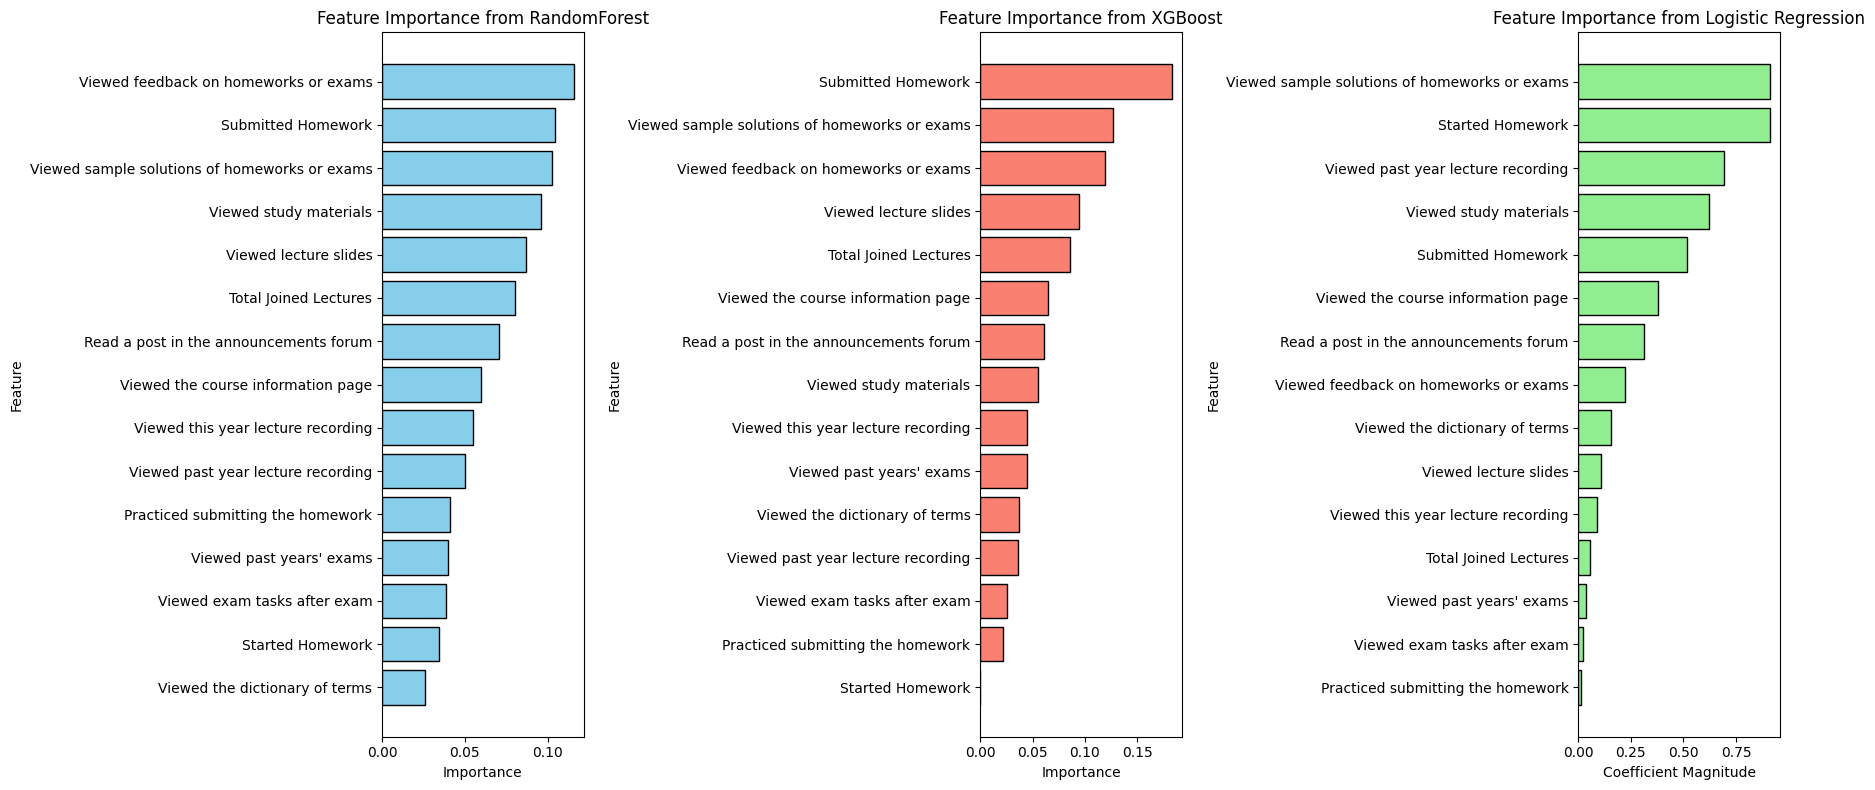

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rf_importance = stacking_model.named_estimators_['rf'].feature_importances_
xgb_importance = stacking_model.named_estimators_['xgb'].feature_importances_
logit_importance = np.abs(stacking_model.named_estimators_['logit'].coef_[0])

rf_sorted_idx = np.argsort(rf_importance)
xgb_sorted_idx = np.argsort(xgb_importance)
logit_sorted_idx = np.argsort(logit_importance)

plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.barh(feature_names[rf_sorted_idx], rf_importance[rf_sorted_idx], color="skyblue", edgecolor="black")
plt.title("Feature Importance from RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.subplot(1, 3, 2)
plt.barh(feature_names[xgb_sorted_idx], xgb_importance[xgb_sorted_idx], color="salmon", edgecolor="black")
plt.title("Feature Importance from XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.subplot(1, 3, 3)
plt.barh(feature_names[logit_sorted_idx], logit_importance[logit_sorted_idx], color="lightgreen", edgecolor="black")
plt.title("Feature Importance from Logistic Regression")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


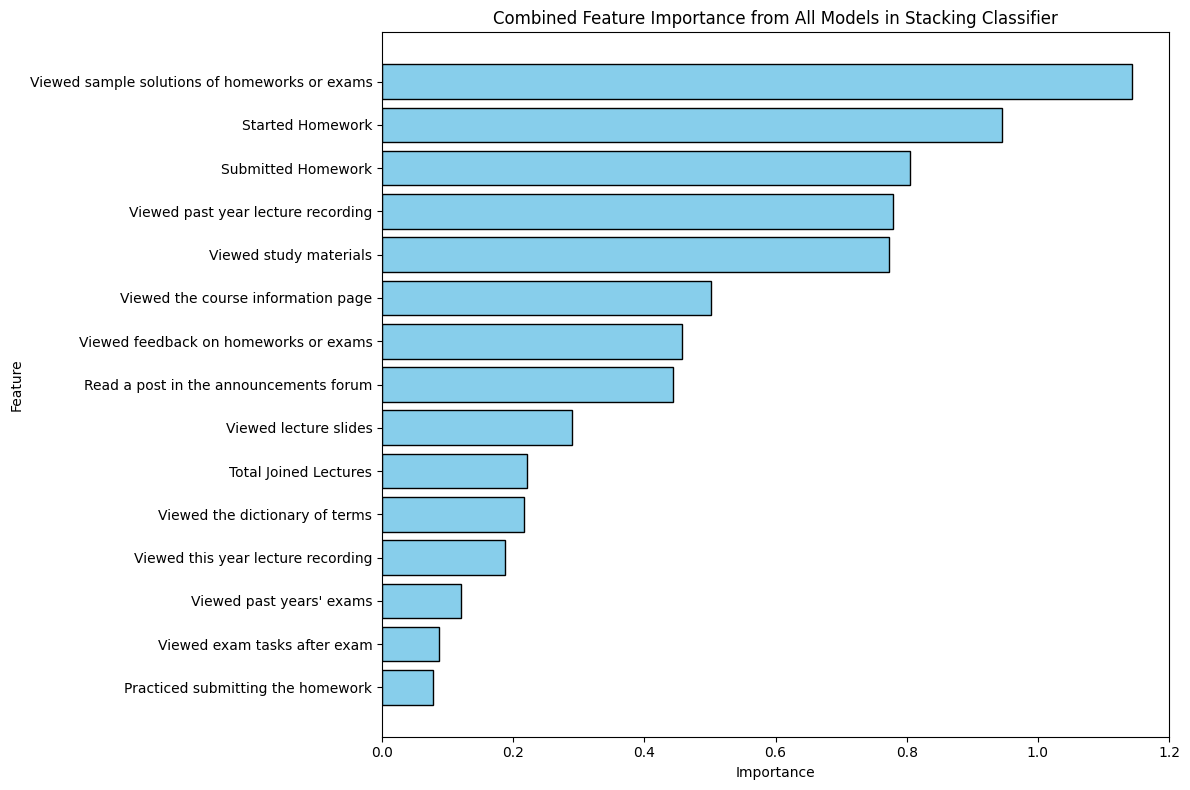

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rf_importance = stacking_model.estimators_[0].feature_importances_
xgb_importance = stacking_model.estimators_[1].feature_importances_
logit_importance = np.abs(stacking_model.estimators_[2].coef_[0])

combined_importance = np.zeros(len(feature_names))

combined_importance += rf_importance
combined_importance += xgb_importance
combined_importance += logit_importance
sorted_idx = np.argsort(combined_importance)

plt.figure(figsize=(12, 8))
plt.barh(np.array(feature_names)[sorted_idx], combined_importance[sorted_idx], color="skyblue", edgecolor="black")
plt.title("Combined Feature Importance from All Models in Stacking Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



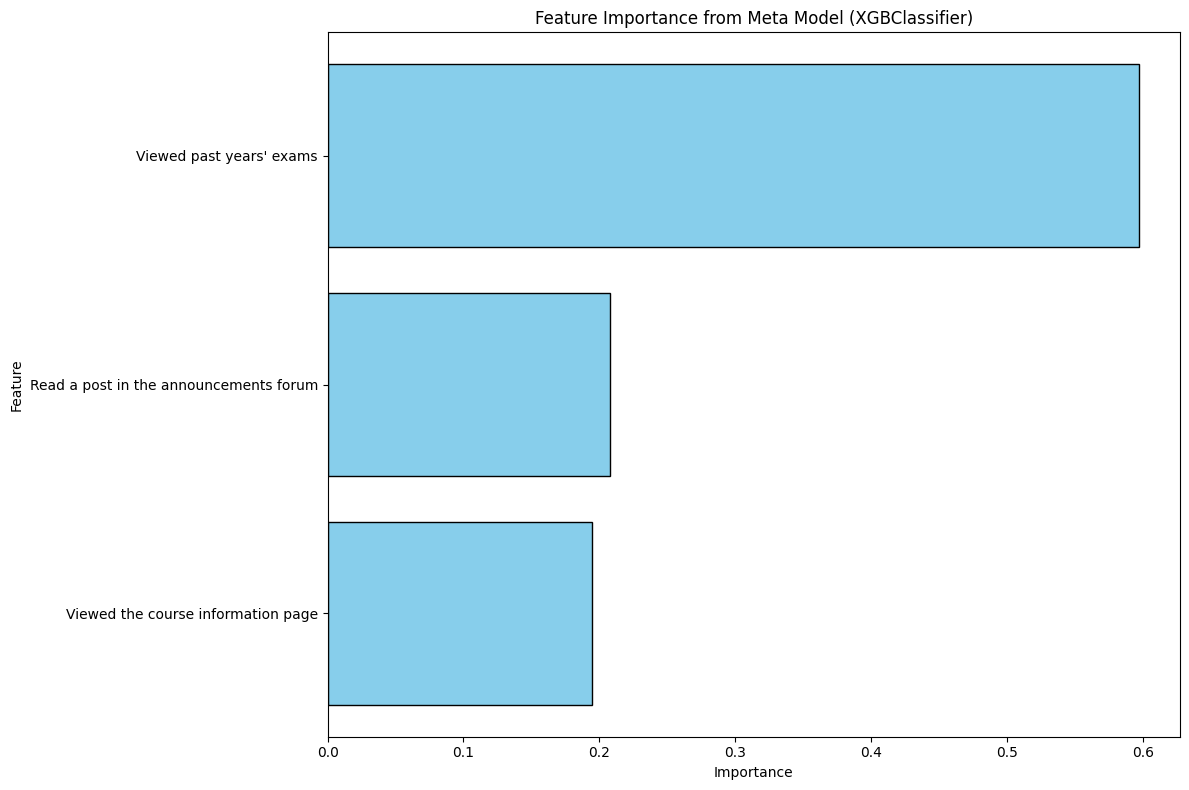

In [ ]:
importance = stacking_model.final_estimator_.feature_importances_

sorted_idx = np.argsort(importance)

plt.figure(figsize=(12, 8))
plt.barh(feature_names[sorted_idx], importance[sorted_idx], color="skyblue", edgecolor="black")
plt.title("Feature Importance from Meta Model (XGBClassifier)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
stacking_model.classes_

array([0, 1])

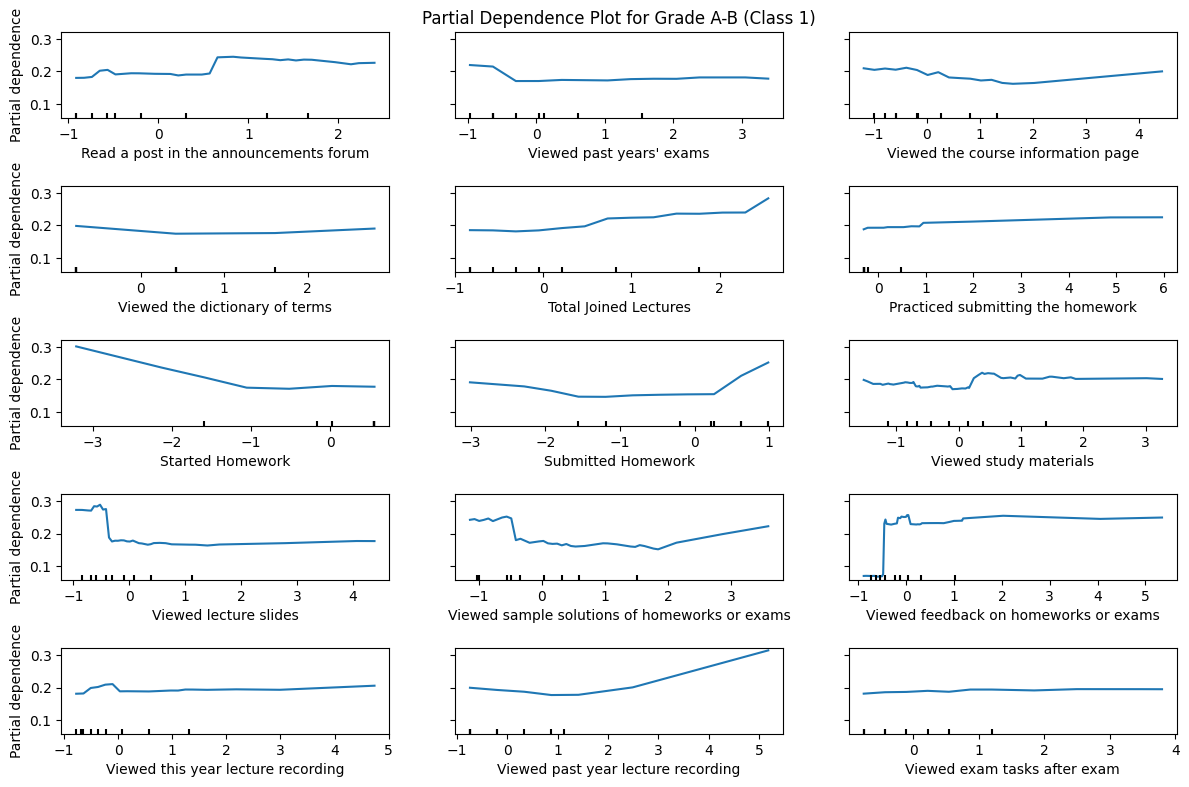

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

class_idx = 1

features = list(range(X_train.shape[1]))

fig, ax = plt.subplots(figsize=(12, 8))

pdp = PartialDependenceDisplay.from_estimator(
    stacking_model,
    X_train,
    features=features,
    target=class_idx,
    feature_names=feature_names,
    ax=ax
)

ax.set_title(f"Partial Dependence Plot for Grade A-B (Class {class_idx})")
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.8)
plt.show()


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(stacking_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-validated accuracy scores: {scores}')
print(f'Mean cross-validated accuracy: {scores.mean():.4f}')

Cross-validated accuracy scores: [0.73333333 0.64285714 0.64285714 0.78571429 0.71428571]
Mean cross-validated accuracy: 0.7038


 **Voting ensemble**

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train, y_train)

log_model = LogisticRegression(solver="lbfgs", max_iter=1000)
log_model.fit(X_train, y_train)

ensemble_model = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('logit', log_model)
], voting='hard')

ensemble_model.fit(X_train, y_train)

y_pred = ensemble_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"Accuracy Score: {accuracy:.4f}")

# plt.figure(figsize=(10, 6))
# plot_importance(xgb_model, importance_type='weight', title="Feature Importance (XGBoost)")
# plt.show()

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:02:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mean Squared Error: 0.2222
Mean Absolute Error: 0.2222
R^2 Score: -0.2857
Accuracy Score: 0.7778


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:02:32] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


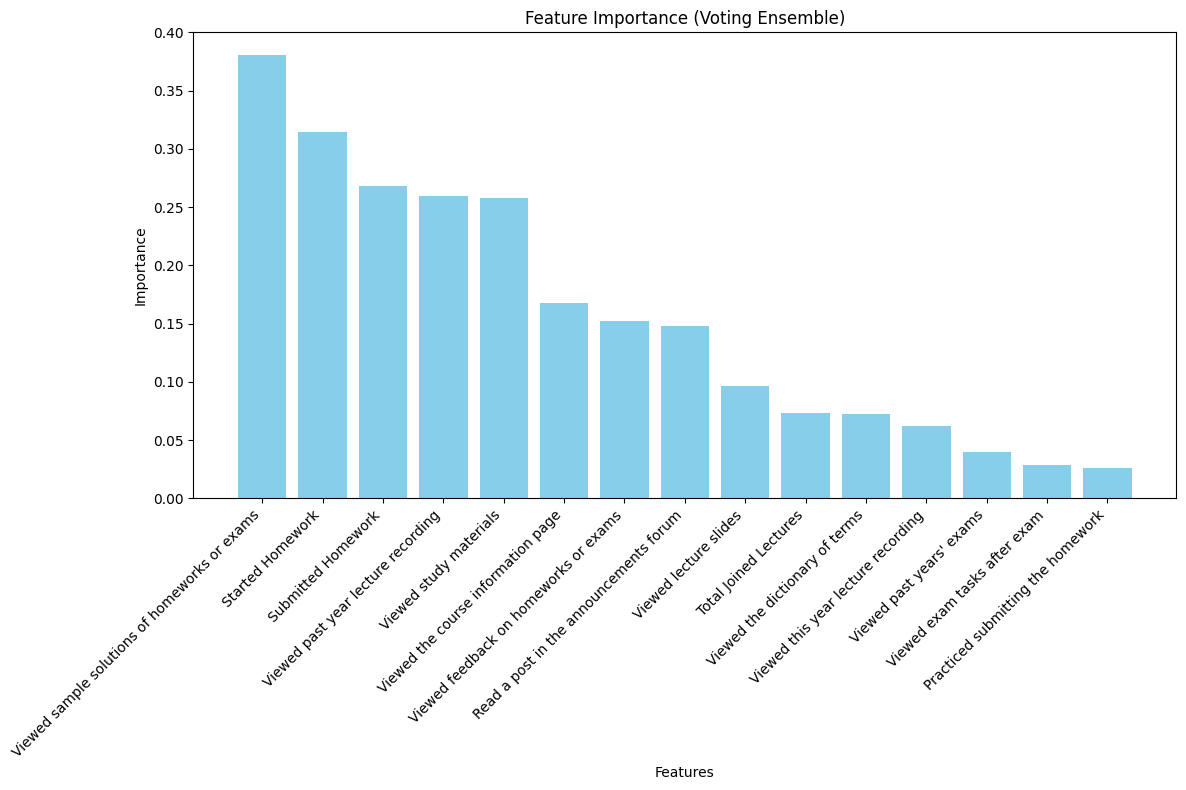

In [ ]:
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

log_importances = np.abs(log_model.coef_[0])

ensemble_importances = (rf_importances + xgb_importances + log_importances) / 3
ensemble_indices = np.argsort(ensemble_importances)[::-1]

#feature_names = X_train.columns
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ensemble_importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
plt.bar(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.title('Feature Importance (Voting Ensemble)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# feature_names = X_train.columns

# plt.figure(figsize=(14, 7))

# plt.bar(range(len(ensemble_importances)), ensemble_importances[ensemble_indices], align='center')
# plt.xticks(range(len(ensemble_importances)), [feature_names[i] for i in ensemble_indices], rotation=90)

# plt.title('Feature Importances for Ensemble Model (Average of RF and XGBoost)')
# plt.xlabel('Feature')
# plt.ylabel('Importance')
# plt.show()

# **Dataset B**

In [ ]:
from statsmodels.api import Logit, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df_B_xgb = df_B.copy()
df_B_xgb = df_B_xgb[df_B_xgb['Grade'] != '-']  # Remove rows with '-' in 'Grade'

# Convert Grade to binary
binary_map = lambda x: 1 if x in ["A", "B"] else 0
df_B_xgb['Grade_binary'] = df_B_xgb['Grade'].map(binary_map)

# Label Encoding for original 'Grade' column (if needed for comparison or other uses)
label_encoder = LabelEncoder()
df_B_xgb['Grade_encoded'] = label_encoder.fit_transform(df_B_xgb['Grade'])

# Separate features and target variable
X = df_B_xgb.drop(columns=['Student', 'Grade', 'Grade_encoded', 'Total', 'Grade_binary'])
feature_names = X.columns  # Save feature names for later
X = X.values  # Convert to numpy array for scaler
y = df_B_xgb['Grade_binary']  # Target variable is 'Grade_binary'

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

base_models = [
    ('rf', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )),
    ('xgb', XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        # use_label_encoder=True,
        random_state=42
    )),
    ('logit', LogisticRegression(max_iter=1000, random_state=42))
]

meta_model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=42)# LogisticRegression(random_state=42) #XGBClassifier(n_estimators=100, max_depth=3, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=3
)

stacking_model.fit(X_train, y_train)

y_pred = stacking_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R2 Score: {r2}")
print(f"Accuracy: {accuracy}")


Mean Squared Error (MSE): 0.30434782608695654
Mean Absolute Error (MAE): 0.30434782608695654
R2 Score: -0.2384615384615385
Accuracy: 0.6956521739130435


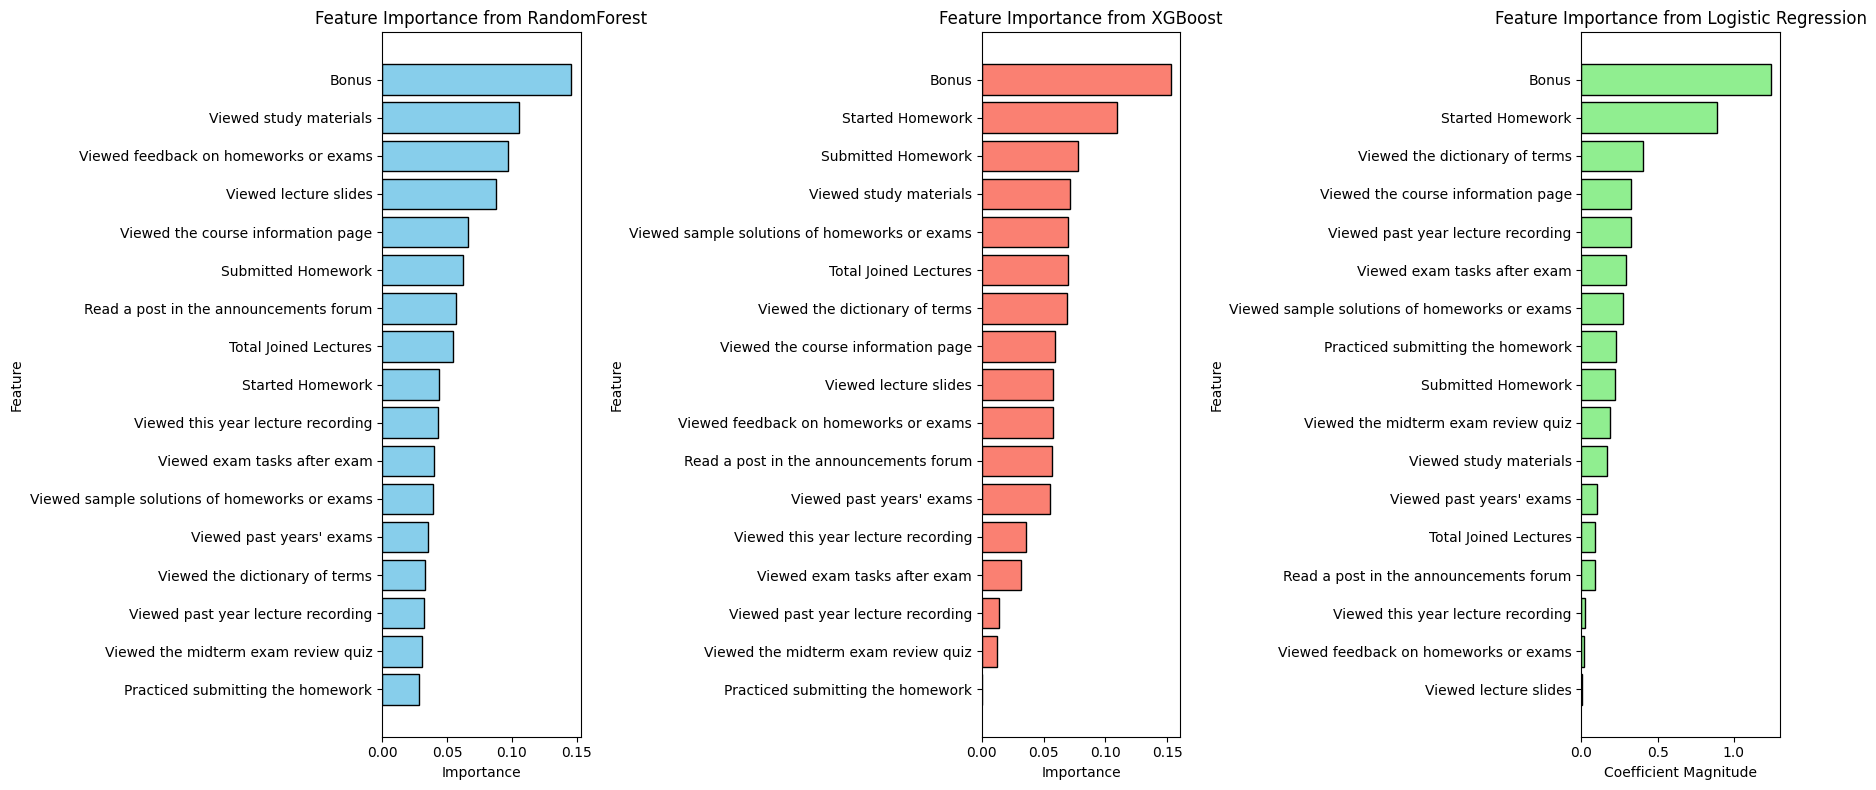

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rf_importance = stacking_model.named_estimators_['rf'].feature_importances_
xgb_importance = stacking_model.named_estimators_['xgb'].feature_importances_
logit_importance = np.abs(stacking_model.named_estimators_['logit'].coef_[0])

rf_sorted_idx = np.argsort(rf_importance)
xgb_sorted_idx = np.argsort(xgb_importance)
logit_sorted_idx = np.argsort(logit_importance)

plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.barh(feature_names[rf_sorted_idx], rf_importance[rf_sorted_idx], color="skyblue", edgecolor="black")
plt.title("Feature Importance from RandomForest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.subplot(1, 3, 2)
plt.barh(feature_names[xgb_sorted_idx], xgb_importance[xgb_sorted_idx], color="salmon", edgecolor="black")
plt.title("Feature Importance from XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.subplot(1, 3, 3)
plt.barh(feature_names[logit_sorted_idx], logit_importance[logit_sorted_idx], color="lightgreen", edgecolor="black")
plt.title("Feature Importance from Logistic Regression")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


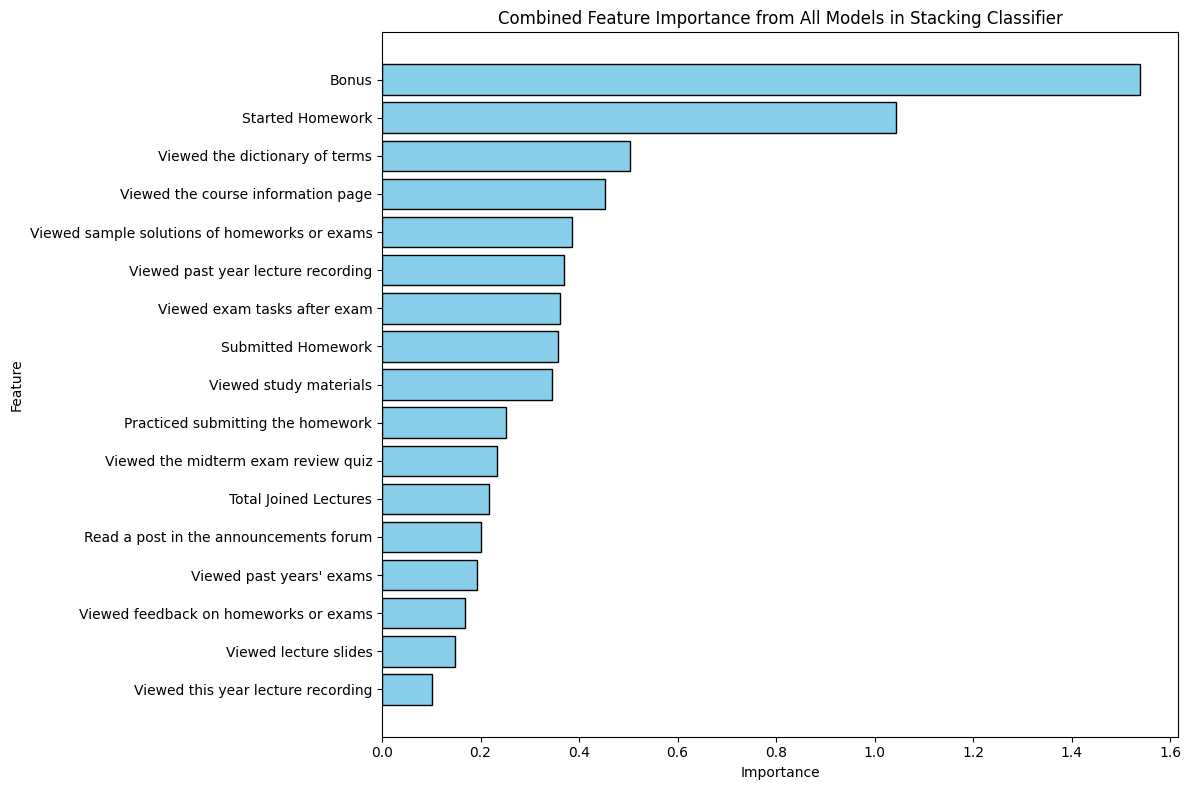

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rf_importance = stacking_model.estimators_[0].feature_importances_
xgb_importance = stacking_model.estimators_[1].feature_importances_
logit_importance = np.abs(stacking_model.estimators_[2].coef_[0])

combined_importance = np.zeros(len(feature_names))

combined_importance += rf_importance
combined_importance += xgb_importance
combined_importance += logit_importance
sorted_idx = np.argsort(combined_importance)

plt.figure(figsize=(12, 8))
plt.barh(np.array(feature_names)[sorted_idx], combined_importance[sorted_idx], color="skyblue", edgecolor="black")
plt.title("Combined Feature Importance from All Models in Stacking Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



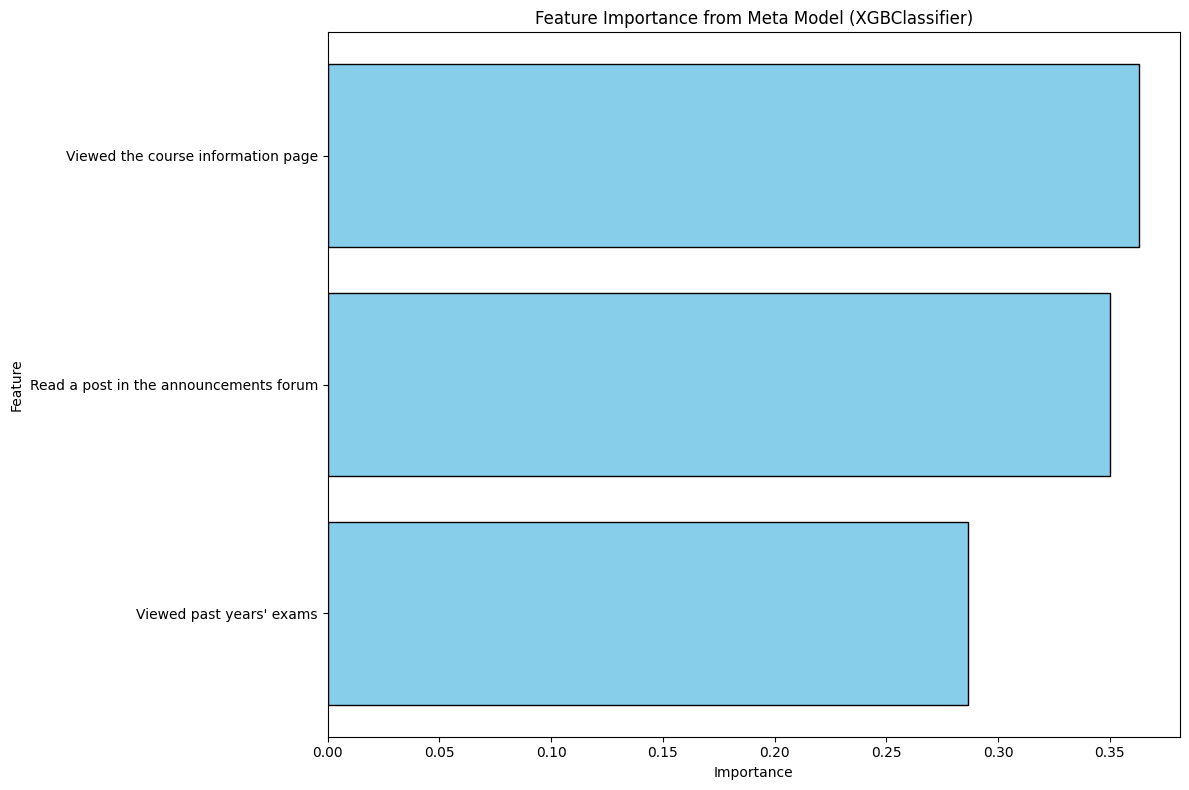

In [ ]:
importance = stacking_model.final_estimator_.feature_importances_

sorted_idx = np.argsort(importance)

plt.figure(figsize=(12, 8))
plt.barh(feature_names[sorted_idx], importance[sorted_idx], color="skyblue", edgecolor="black")
plt.title("Feature Importance from Meta Model (XGBClassifier)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(stacking_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-validated accuracy scores: {scores}')
print(f'Mean cross-validated accuracy: {scores.mean():.4f}')

Cross-validated accuracy scores: [0.73684211 0.55555556 0.66666667 0.72222222 0.61111111]
Mean cross-validated accuracy: 0.6585


**Voting ensemble**

In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt


rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(X_train, y_train)

log_model = LogisticRegression(solver="lbfgs", max_iter=1000)
log_model.fit(X_train, y_train)

ensemble_model = VotingClassifier(estimators=[
    ('rf', rf_model),
    ('xgb', xgb_model),
    ('logit', log_model)
], voting='hard')

ensemble_model.fit(X_train, y_train)

y_pred = ensemble_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")
print(f"Accuracy Score: {accuracy:.4f}")

# plt.figure(figsize=(10, 6))
# plot_importance(xgb_model, importance_type='weight', title="Feature Importance (XGBoost)")
# plt.show()

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:29:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:29:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mean Squared Error: 0.1739
Mean Absolute Error: 0.1739
R^2 Score: 0.2923
Accuracy Score: 0.8261


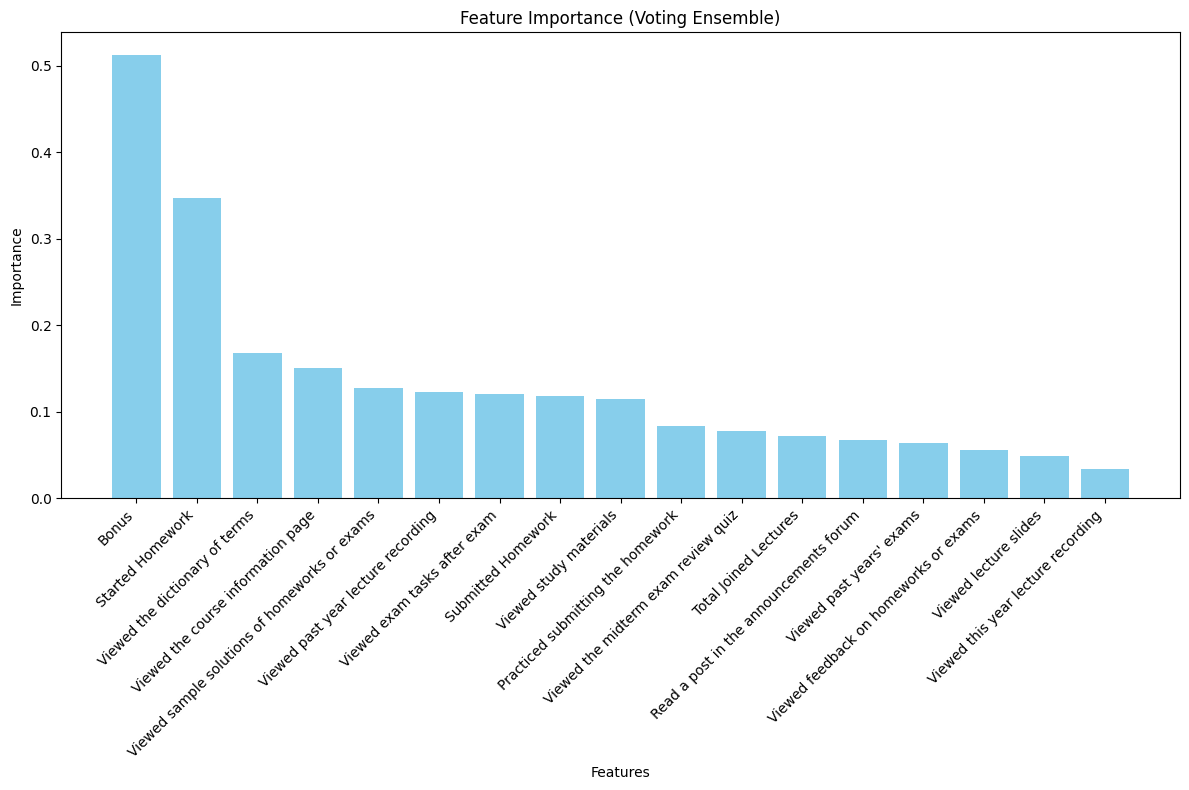

In [ ]:
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

log_importances = np.abs(log_model.coef_[0])

ensemble_importances = (rf_importances + xgb_importances + log_importances) / 3
ensemble_indices = np.argsort(ensemble_importances)[::-1]

#feature_names = X_train.columns
importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': ensemble_importances
}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(12, 8))
plt.bar(importances_df['Feature'], importances_df['Importance'], color='skyblue')
plt.title('Feature Importance (Voting Ensemble)')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
# feature_names = X_train.columns

# plt.figure(figsize=(14, 7))

# plt.bar(range(len(ensemble_importances)), ensemble_importances[ensemble_indices], align='center')
# plt.xticks(range(len(ensemble_importances)), [feature_names[i] for i in ensemble_indices], rotation=90)

# plt.title('Feature Importances for Ensemble Model (Average of RF and XGBoost)')
# plt.xlabel('Feature')
# plt.ylabel('Importance')
# plt.show()